<a href="https://colab.research.google.com/github/tasneemsk500/Algthms_Machine_Learning_Practice/blob/main/A1/Tasneem_Shahnewaz_Khan_A1_EAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CAP4611
#Tasneem Shahnewaz Khan
#A1 EAD

#A. Basic Setup

1. Import required libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno


2. Load the dataset into a DataFrame and display the number of rows and columns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A1 EAD/telco_churn2.csv") #read the file from the file path
print(df.shape) #print the shape

(7043, 24)


3. Use describe() to show summary statistics of numerical columns

In [ ]:
print(df.describe()) #print the statistical description

       SeniorCitizen       tenure  MonthlyCharges  ActiveCountryCode
count    7043.000000  7043.000000     7043.000000             7043.0
mean        0.162147    32.371149       64.761692                1.0
std         0.368612    24.559481       30.090047                0.0
min         0.000000     0.000000       18.250000                1.0
25%         0.000000     9.000000       35.500000                1.0
50%         0.000000    29.000000       70.350000                1.0
75%         0.000000    55.000000       89.850000                1.0
max         1.000000    72.000000      118.750000                1.0


4. Explain any interesting or useful statistics you observed from the summary

From the above statistics, I noticed that the describe() method
treated the values under SeniorCitizen and ActiveCountryCode as
numerical values.

SeniorCitizen according to the dataset is a binary type with
only 0 and 1. Thus, the mean, std doesn't make sense. However,
as per the instructions, if 1 represents that the person is a senior
citizen, then we can deduce that around 16% of the people are senior.

The ActiveCountryCode here is actually a nominial value and the mean
of the values doesn't make semantic sense. Each values represent the
country or region of the customer. Thus, calculating mean and std
deviation isn't helpful.

5. Display the first 5 and last 5 rows of the DataFrame

In [ ]:
print(df.head(5)) #the top 5 rows

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0  No phone service             DSL             No  ...              No   
1                No             DSL            Yes  ...              No   
2                No             DSL            Yes  ...              No   
3  No phone service             DSL            Yes  ...              No   
4                No     Fiber optic             No  ...              No   

         Contract PaperlessBilling              PaymentMethod Monthl

In [ ]:
print(df.tail(5)) #the bottom 5 rows

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     StreamingMovies        Contract PaperlessBilling  \
7038             Yes        One year              Yes   
7039          

6. List all numerical columns

In [ ]:
#select the numerical columns
numeric_features = df.select_dtypes(include=[np.number])
print(numeric_features.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'ActiveCountryCode'], dtype='object')


7. List all categorical columns

In [ ]:
#select the object data type
categorical_features = df.select_dtypes(include=[object])
print(categorical_features.columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Education', 'SupportTicketID', 'Churn'],
      dtype='object')


#B. Missing Values Analysis

1. Display column-wise count of missing values in descending order

In [ ]:
nulls = df.isnull().sum().to_frame('nulls') #sum up nulls and make a df
# print(nulls)
nulls.sort_values("nulls", inplace = True, ascending = False) #sort it by descending order

for index, row in nulls.iterrows(): #print it in well formatted way
 print(index, row[0])

Education 5679
customerID 0
SeniorCitizen 0
gender 0
Dependents 0
tenure 0
PhoneService 0
Partner 0
MultipleLines 0
InternetService 0
OnlineBackup 0
OnlineSecurity 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
DeviceProtection 0
Contract 0
PaperlessBilling 0
MonthlyCharges 0
PaymentMethod 0
TotalCharges 0
SupportTicketID 0
ActiveCountryCode 0
Churn 0


/tmp/ipykernel_547/3852061482.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index, row[0])


2. Display column-wise percentage of missing values in descending order

In [ ]:
percentage = df.isnull().mean()*100 #use the mean * 100 from the webcourse to calculate the percentage
percentage = percentage.to_frame("nulls") #convert it to a dataframe
percentage.sort_values("nulls", inplace = True, ascending = False) #sort in descending order

for index, row in percentage.iterrows(): #go through every loops
 print(index, row[0])

Education 80.63325287519523
customerID 0.0
SeniorCitizen 0.0
gender 0.0
Dependents 0.0
tenure 0.0
PhoneService 0.0
Partner 0.0
MultipleLines 0.0
InternetService 0.0
OnlineBackup 0.0
OnlineSecurity 0.0
TechSupport 0.0
StreamingTV 0.0
StreamingMovies 0.0
DeviceProtection 0.0
Contract 0.0
PaperlessBilling 0.0
MonthlyCharges 0.0
PaymentMethod 0.0
TotalCharges 0.0
SupportTicketID 0.0
ActiveCountryCode 0.0
Churn 0.0


/tmp/ipykernel_547/4260471917.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index, row[0])


3. The TotalCharges column contains some blank strings that are not detected as NaN by default. Convert TotalCharges to numeric using pd.to_numeric() with errors='coerce' and then re-check for missing values.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Recheck missing values
# missing = df.isnull().sum()
# missing = missing[missing>0]
# missing.sort_values(inplace = True)

# print(missing)

counting missing values

In [ ]:
nulls = df.isnull().sum().to_frame('nulls') #sum up nulls and make a df
# print(nulls)
nulls.sort_values("nulls", inplace = True, ascending = False) #sort it by descending order

for index, row in nulls.iterrows(): #print it in well formatted way
 print(index, row[0])

Education 5679
TotalCharges 11
customerID 0
gender 0
Dependents 0
tenure 0
SeniorCitizen 0
Partner 0
MultipleLines 0
PhoneService 0
InternetService 0
OnlineSecurity 0
TechSupport 0
StreamingTV 0
OnlineBackup 0
DeviceProtection 0
Contract 0
StreamingMovies 0
PaymentMethod 0
PaperlessBilling 0
MonthlyCharges 0
SupportTicketID 0
ActiveCountryCode 0
Churn 0


/tmp/ipykernel_547/3852061482.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index, row[0])


percentage of missing values

In [ ]:
percentage = df.isnull().mean()*100 #use the mean * 100 from the webcourse to calculate the percentage
percentage = percentage.to_frame("nulls") #convert it into dataframw
percentage.sort_values("nulls", inplace = True, ascending = False) #descending order

for index, row in percentage.iterrows(): #go through every loops
 print(index, row[0])

Education 80.63325287519523
TotalCharges 0.1561834445548772
customerID 0.0
gender 0.0
Dependents 0.0
tenure 0.0
SeniorCitizen 0.0
Partner 0.0
MultipleLines 0.0
PhoneService 0.0
InternetService 0.0
OnlineSecurity 0.0
TechSupport 0.0
StreamingTV 0.0
OnlineBackup 0.0
DeviceProtection 0.0
Contract 0.0
StreamingMovies 0.0
PaymentMethod 0.0
PaperlessBilling 0.0
MonthlyCharges 0.0
SupportTicketID 0.0
ActiveCountryCode 0.0
Churn 0.0


/tmp/ipykernel_547/3876508441.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index, row[0])


4. Create a bar plot showing only columns with missing values, ordered from least missing (left) to most missing (right)

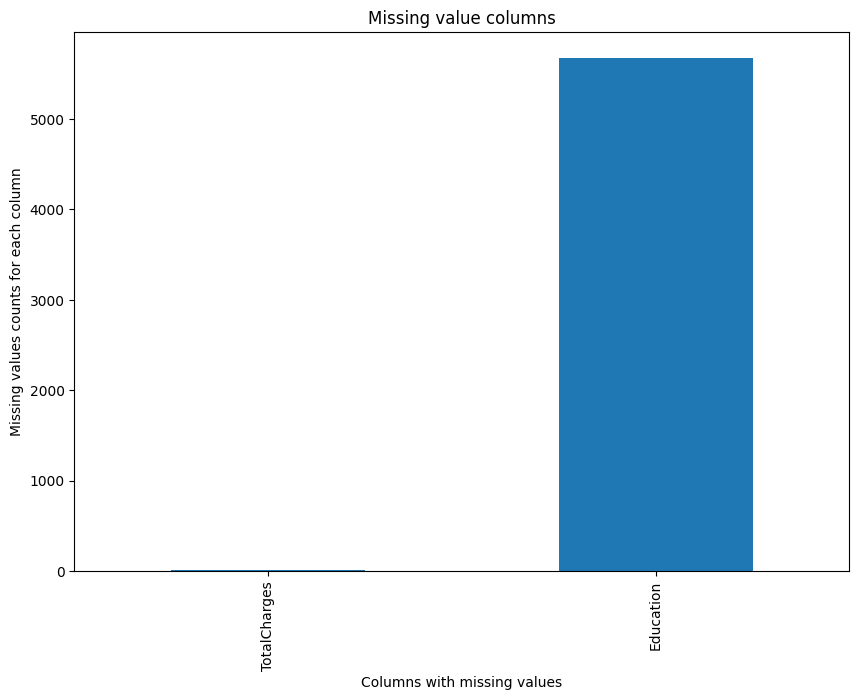

In [ ]:
#from webcourse missing value counting
missing = df.isnull().sum() #sum up the null values
missing = missing[missing>0] #only those that have null value accumulations
missing.sort_values(inplace = True)

plt.figure(figsize = (10, 7)) #specify size
missing.plot.bar()
plt.title("Missing value columns")
plt.xlabel("Columns with missing values")
plt.ylabel("Missing values counts for each column")
plt.show()

5. Use missingno to generate and interpret

*   Matrix plot (using a sample of 200 rows)

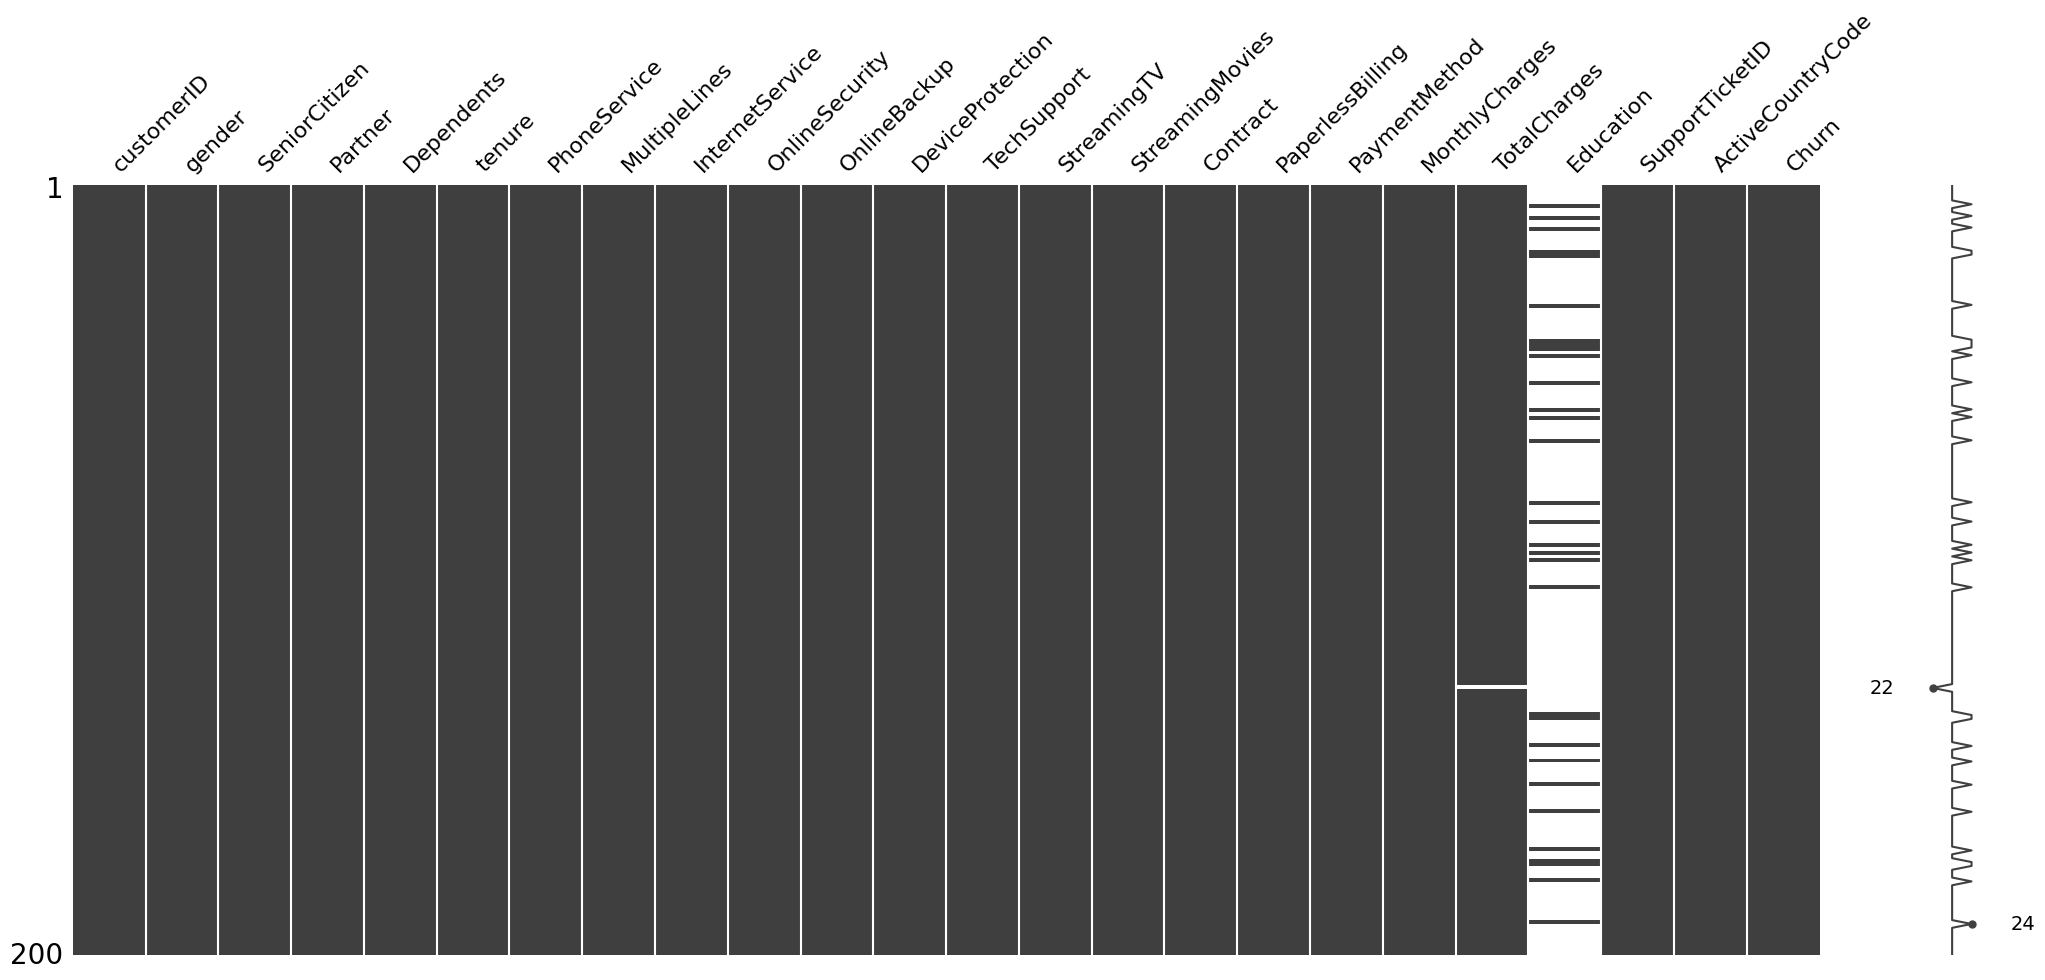

In [ ]:
msno.matrix(df.sample(200))
plt.show()

5. Use missingno to generate and interpret

*   In the msno matrix, what do the right-most and left-most values represent in the spark line? Answer it based on the numbers you got in your plot

The right-most value of the spark line represents the maximum number of completeness (non-null column values). Here the max number is 24 where there is at least one row containing all 24 non-null column values.

On the other hand on the left-most side of the spark line, 23, means the minimum number of completeness where there is at least one row with 23 non-null values. Thus, 24-23 giving 1 means at least one row is missing out just one column.

5. Use missingno to generate and interpret

*   Why is it not interesting to use the missingno heatmap for this data set? What is the values 1 and -1 mean in missngno heatmap?

<Axes: >

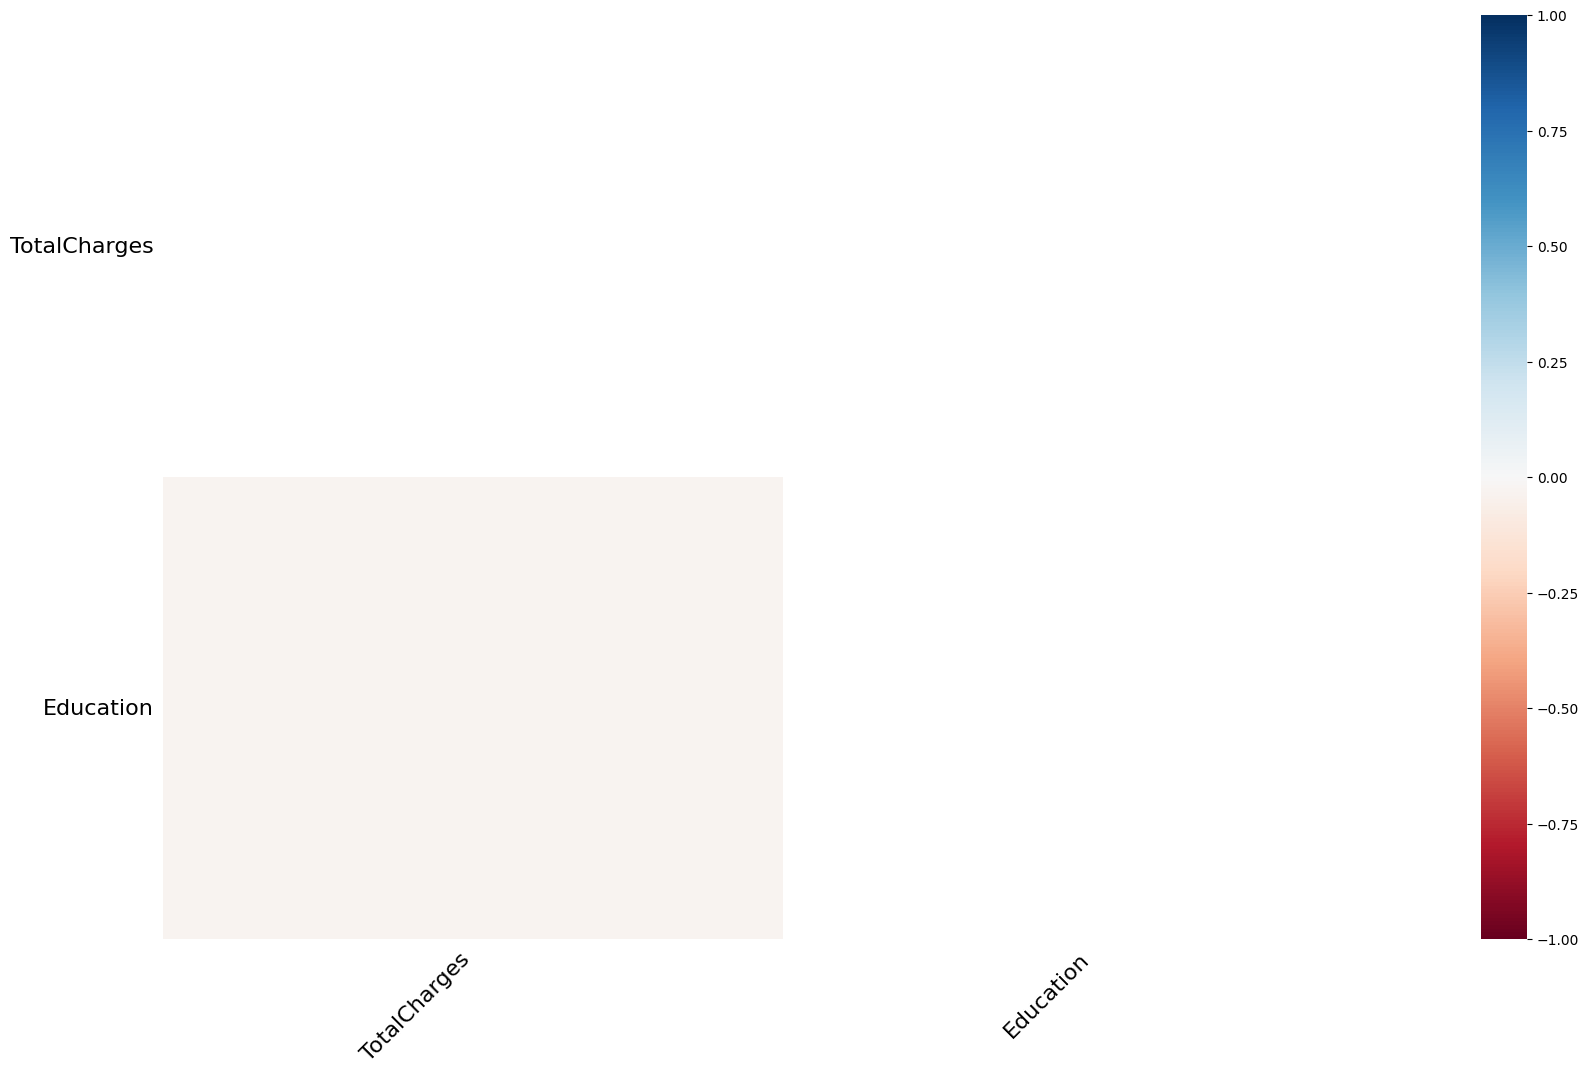

In [ ]:
msno.heatmap(df)

The heatmap is for comparing measures nullity correlation: how strongly the presence or absence of one variable affects the presence of another. Here, based on the above heatmap, we can see that since we have only two missing value columns, TotalChages and Education, there's not enough missing value patterns to analyse.

+1 represents that presence of null values in one column is positively correlated with the presence of null values in another column.

-1 means that presence of null values in one column is anti-correlated with the presence of null values in another column.

6. List columns with missing values and discuss how to deal with each of them as an itemized list, solution, and reasoning behind your solution

In [ ]:
#from webcourse
missing = df.isnull().sum()
missing = missing[missing>0]
missing.sort_values(inplace = True, ascending=False)
print(missing)

Education       5679
TotalCharges      11
dtype: int64


In [ ]:
#from webcourse
missing_percentage = df.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage>0]
missing_percentage.sort_values(inplace = True, ascending=False)
print(missing_percentage)

Education       80.633253
TotalCharges     0.156183
dtype: float64


Using the previous missing colunn count and the matrix map, I've decided the following:

*   Education: we'll drop the education column as by the rule of thumb, more than 60% of the values are missing. However, it might lead to some potential bias unless it's not affecting the target value.
*   TotalCharges: As for the TotalCharges column, we can impute the missing value by replacing it with a mean, median, mode, or other aggregate value since a small number of features are missing (generally less than 30%)
We can also build a predictive [regression] model based on the dataset to try and predict the missing feature

#C. Understanding Categorical Attributes

For each categorical attribute, including the target:

1. Create a seaborn bar plot showing category counts

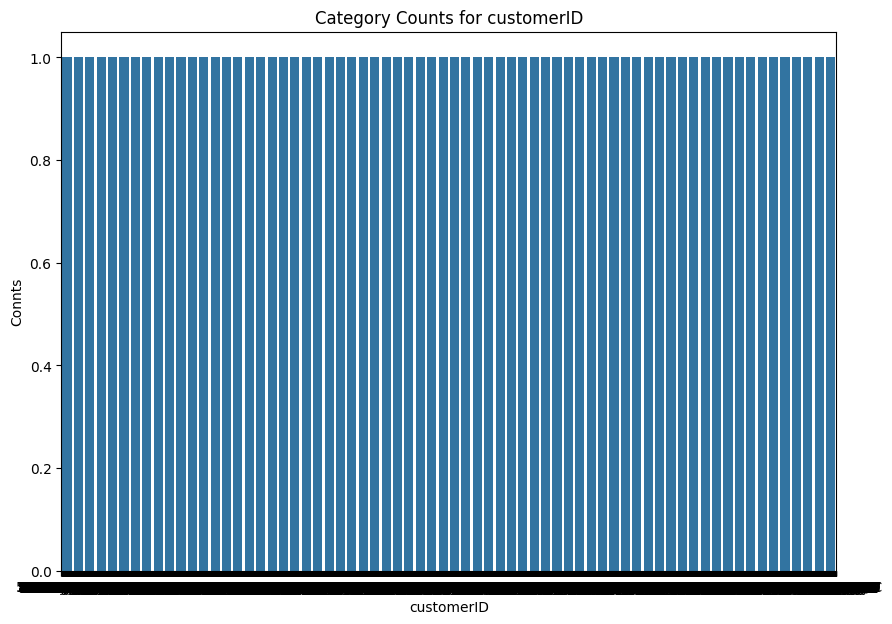

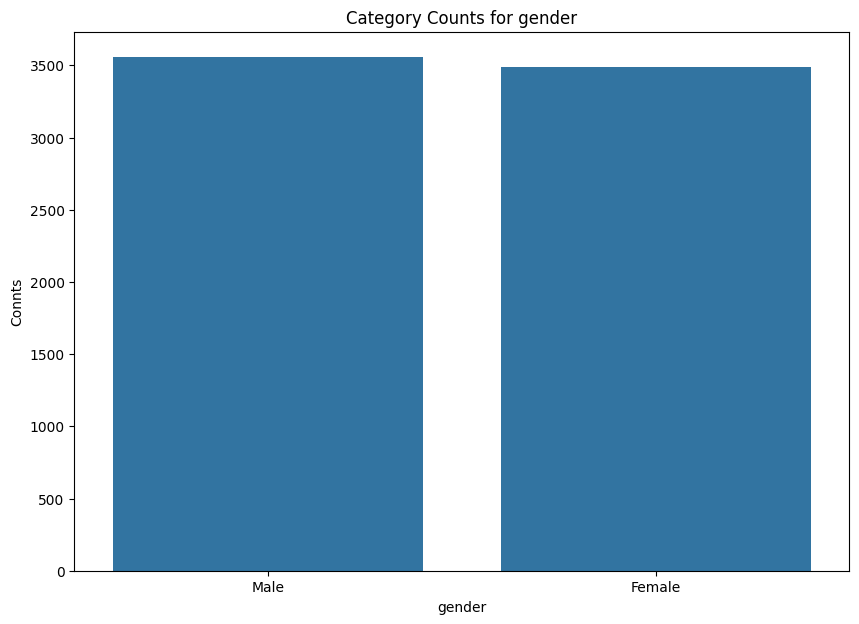

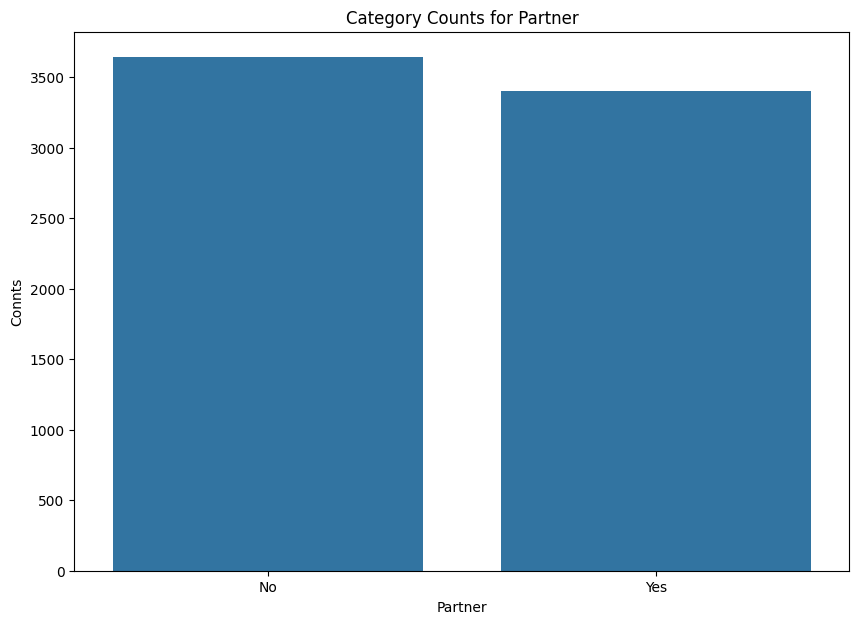

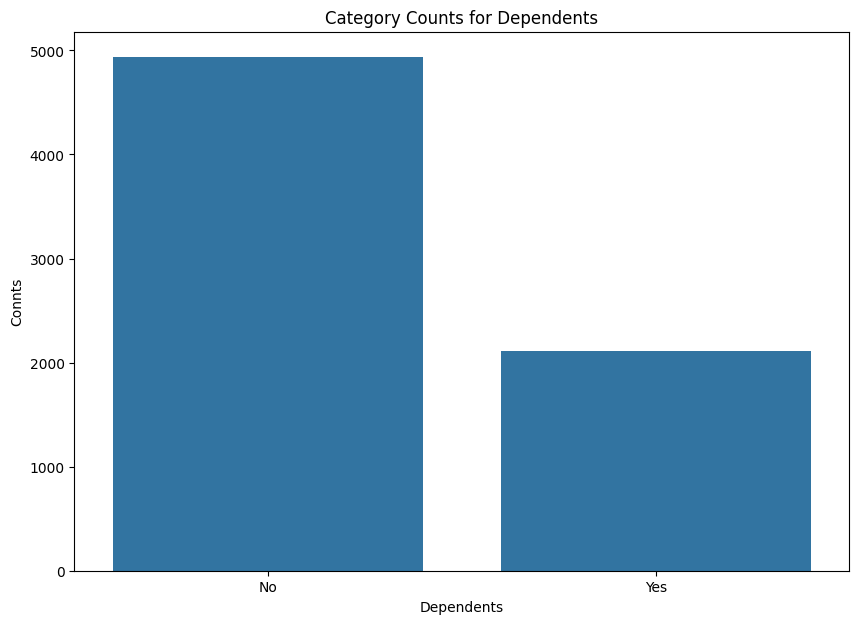

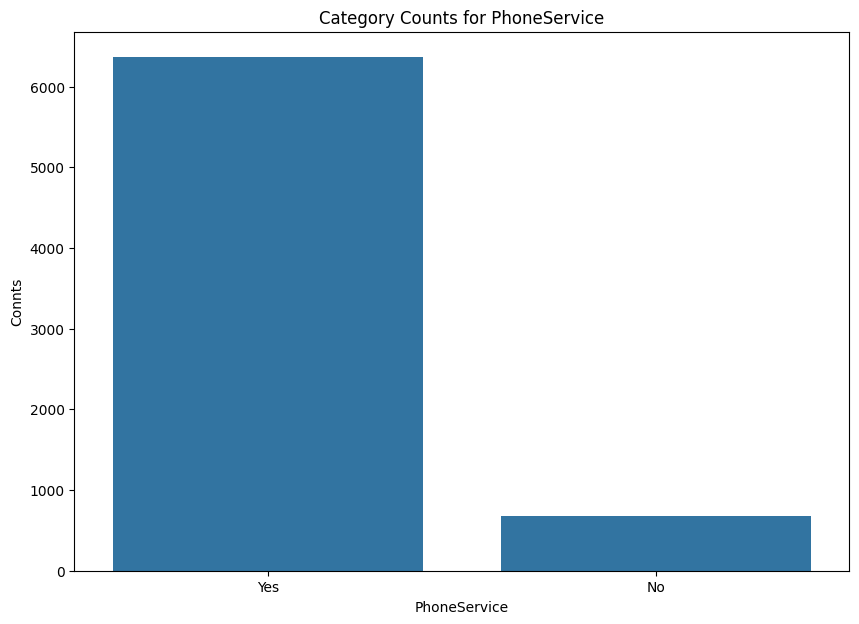

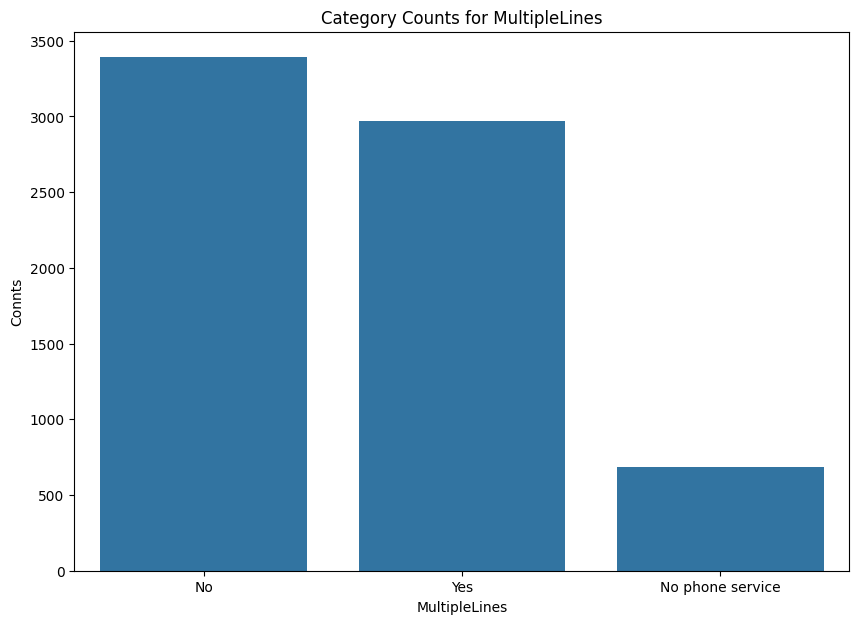

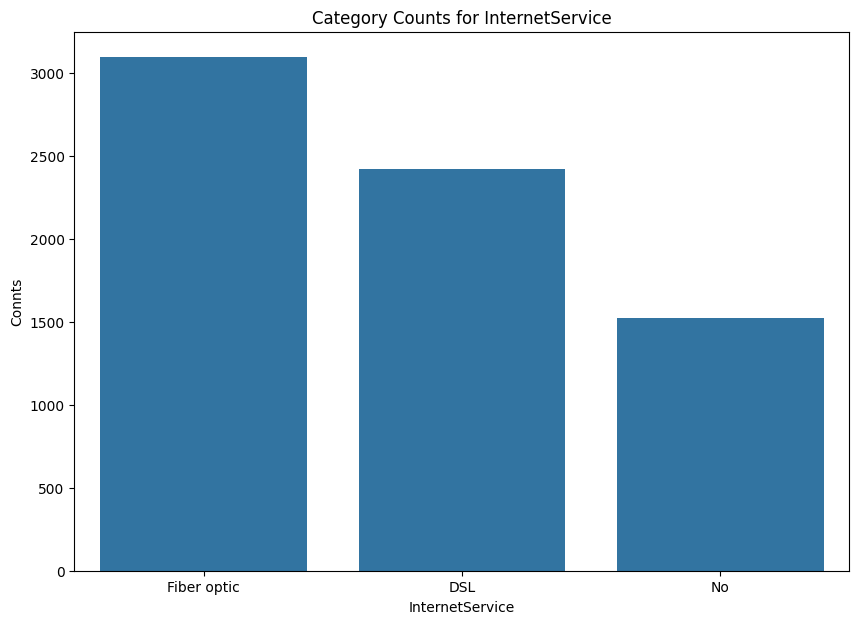

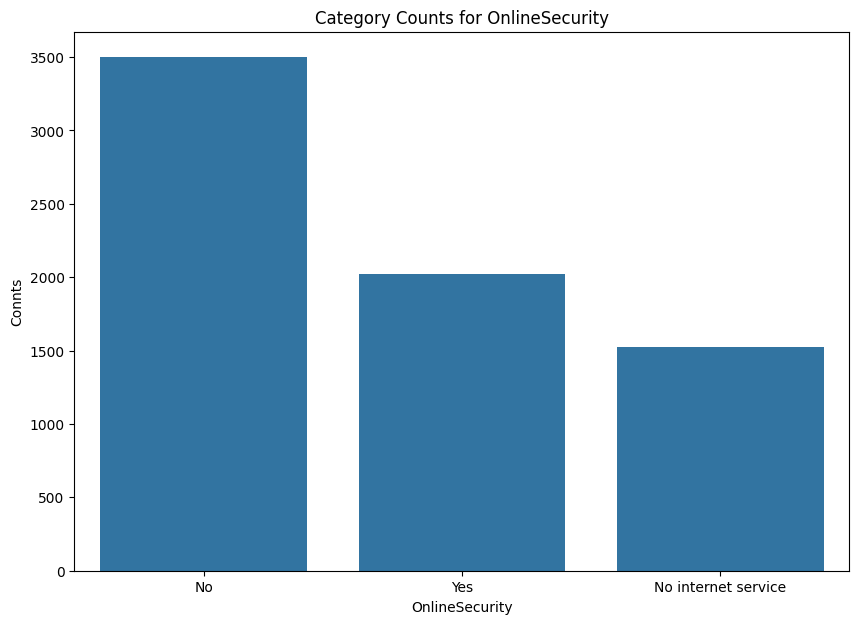

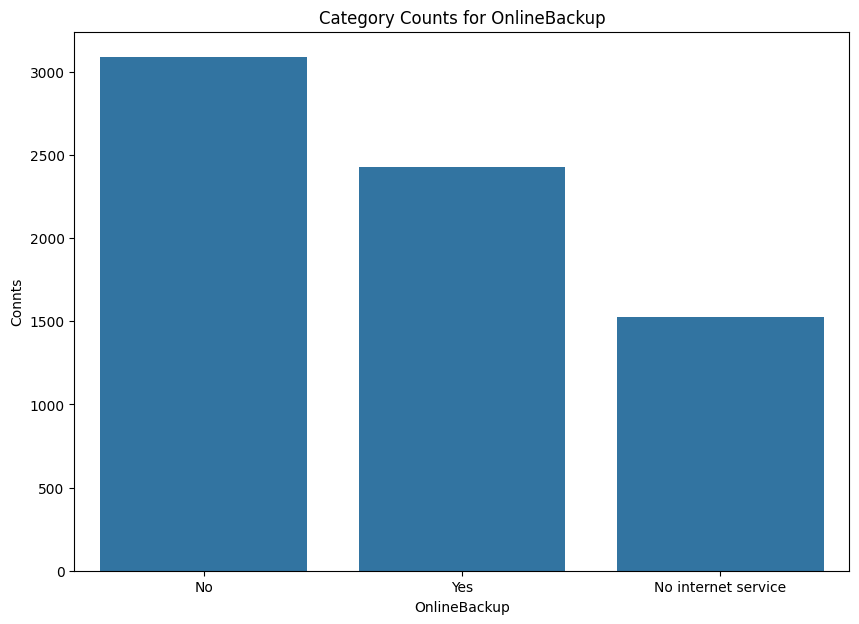

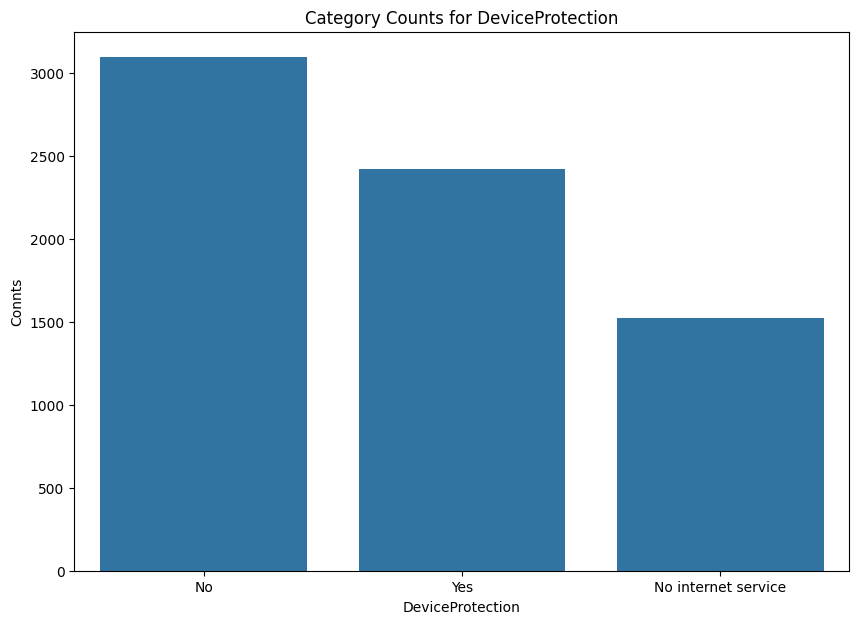

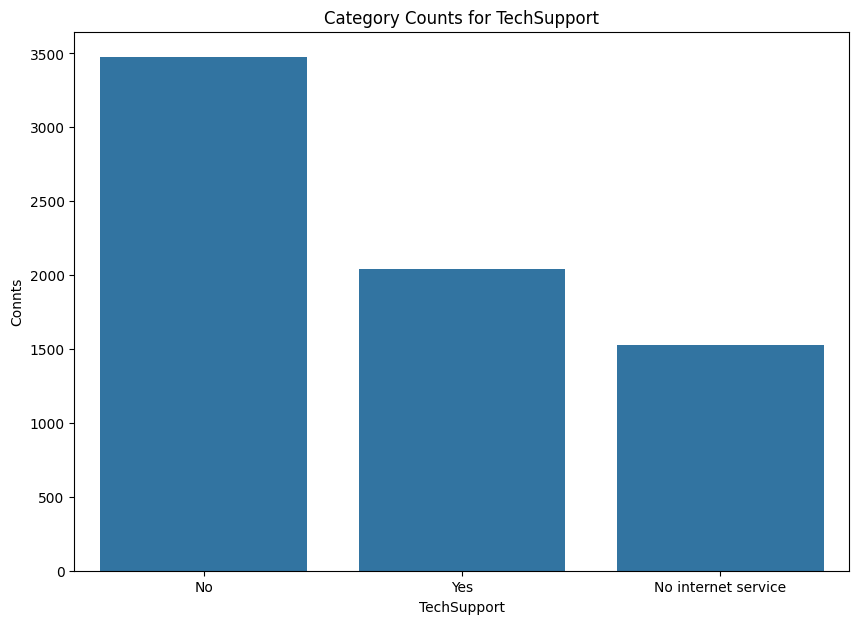

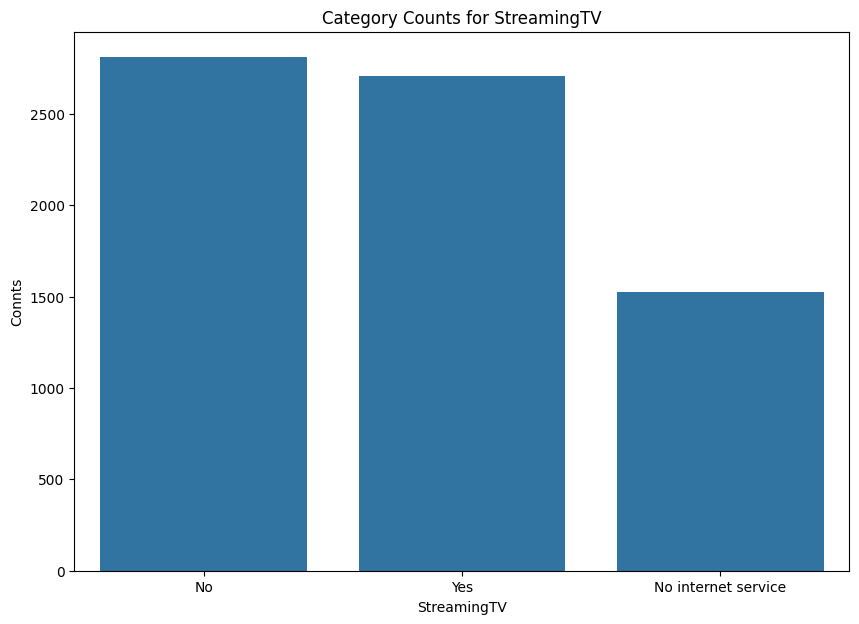

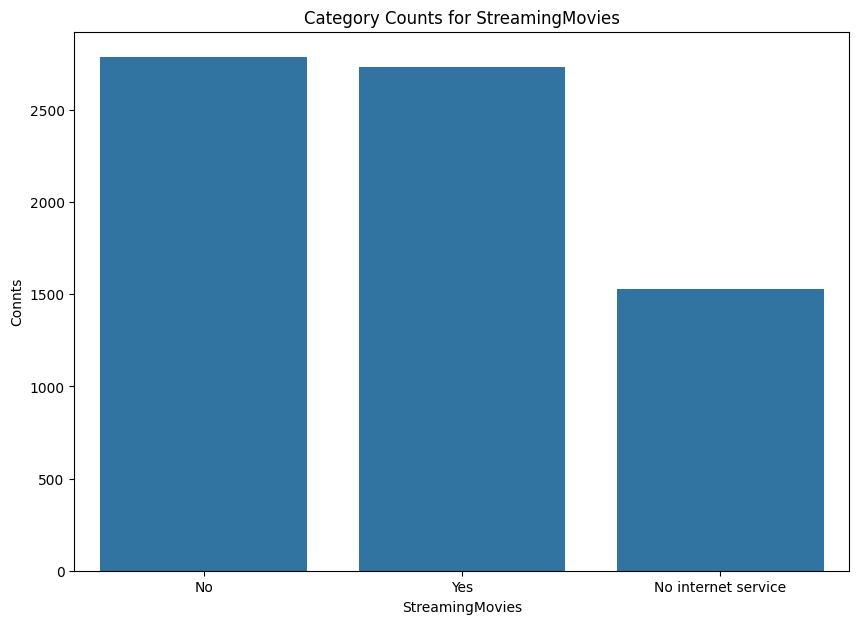

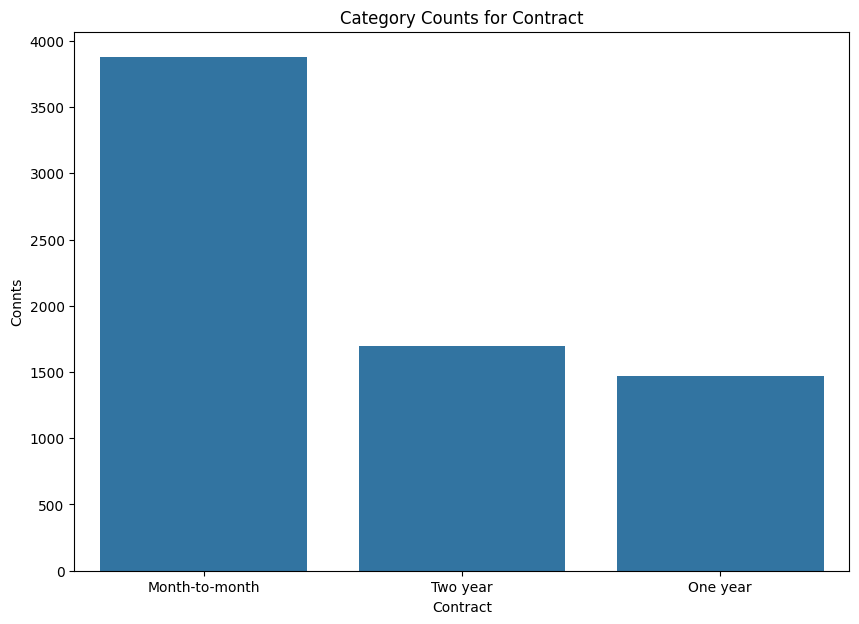

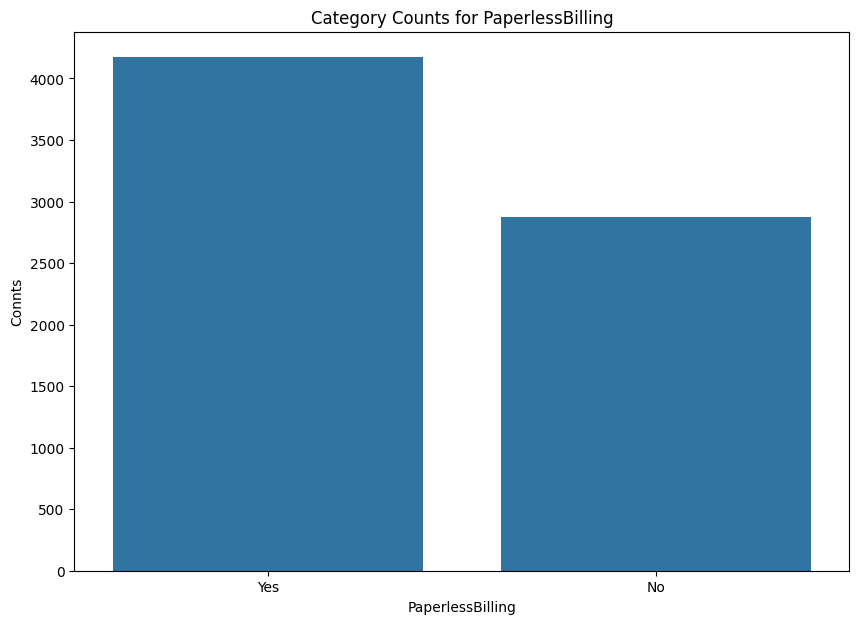

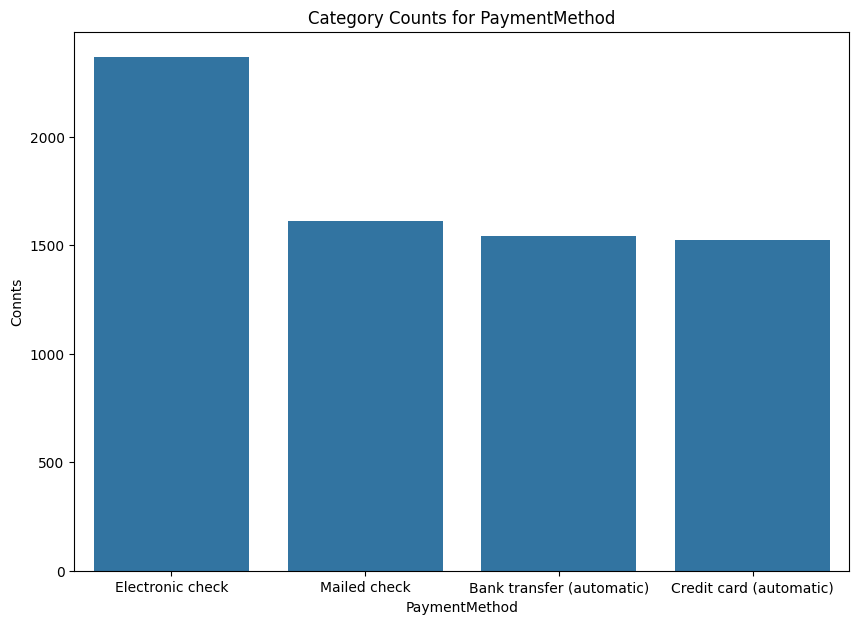

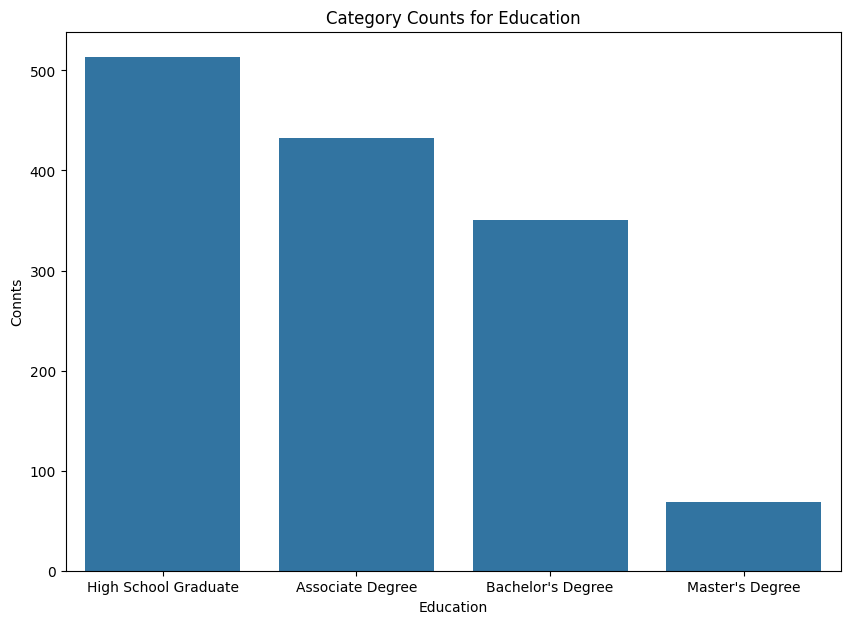

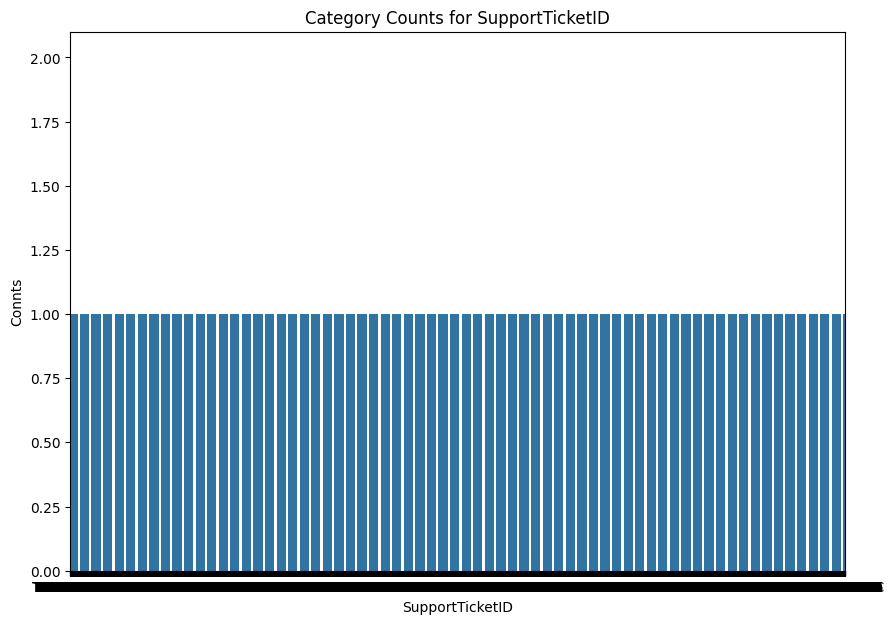

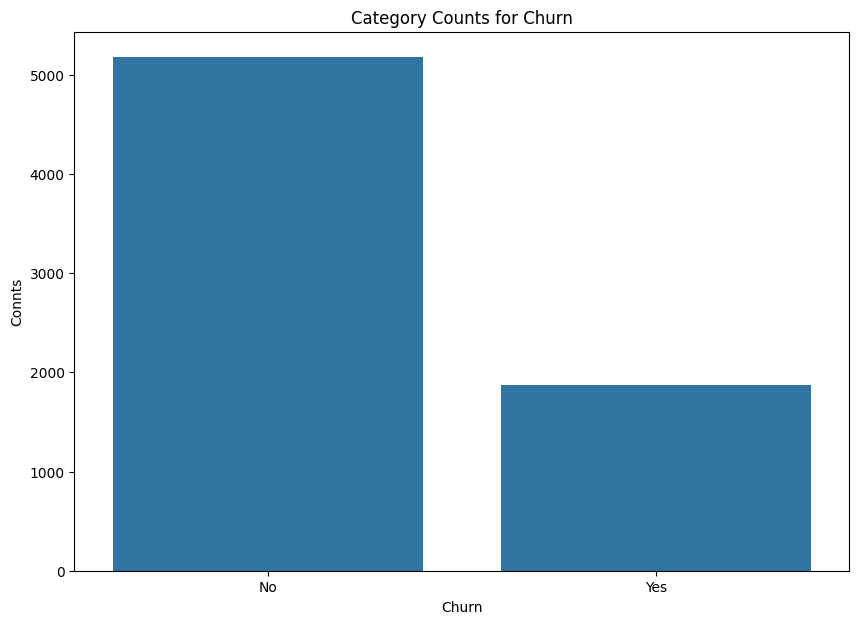

In [ ]:
#recalculate the categorial features
categorical_features = df.select_dtypes(include=[object])
#go through every attributes
for col in categorical_features:
  plt.figure(figsize = (10, 7)) #set the size

  #count the values for each categories
  count = df[col].value_counts()

  #count is an array and must be passed directly
  sns.barplot(x=count.index, y=count.values)

  #label the graphs
  plt.title(f'Category Counts for {col}')
  plt.xlabel(f'{col}')
  plt.ylabel('Counts')

  #display
  plt.show()

2. Create a seaborn countplot of the feature against the target

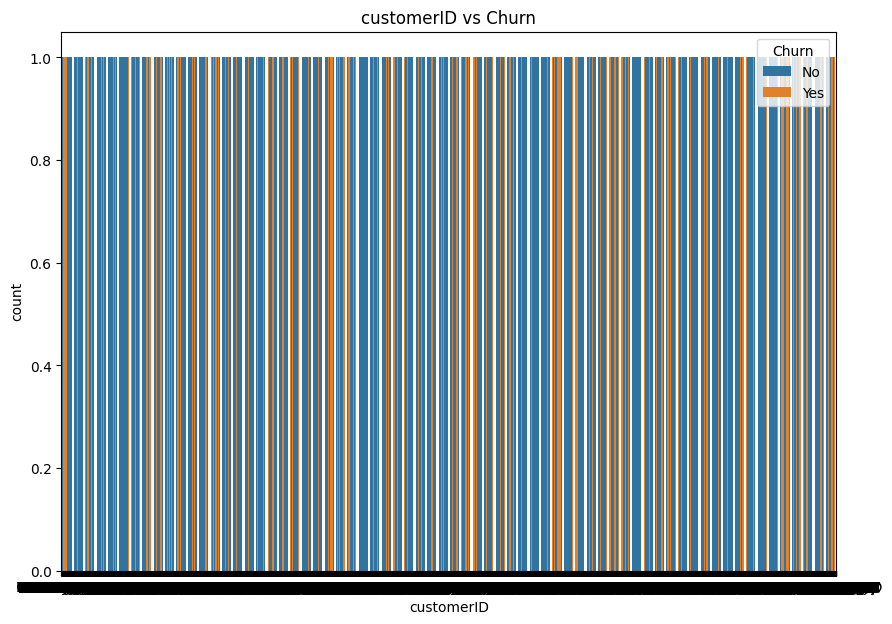

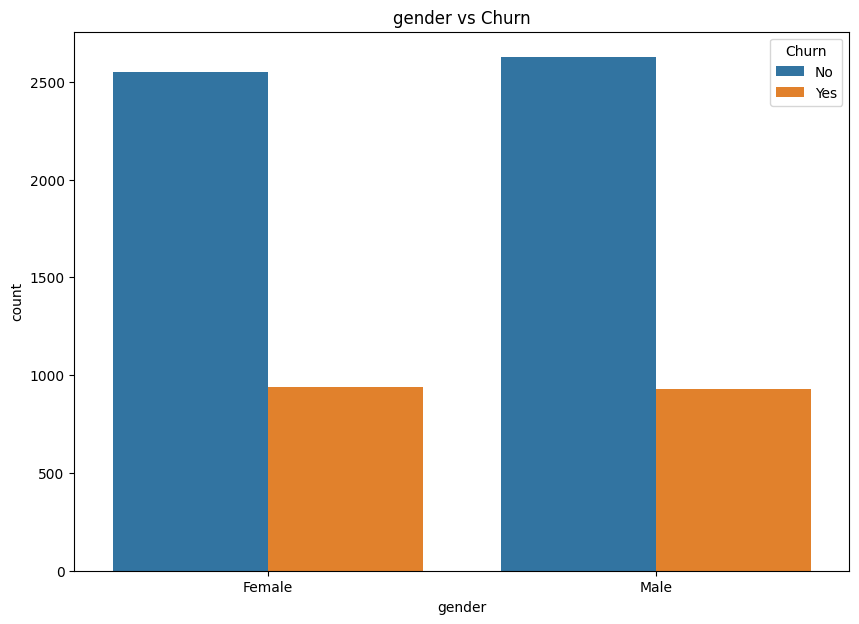

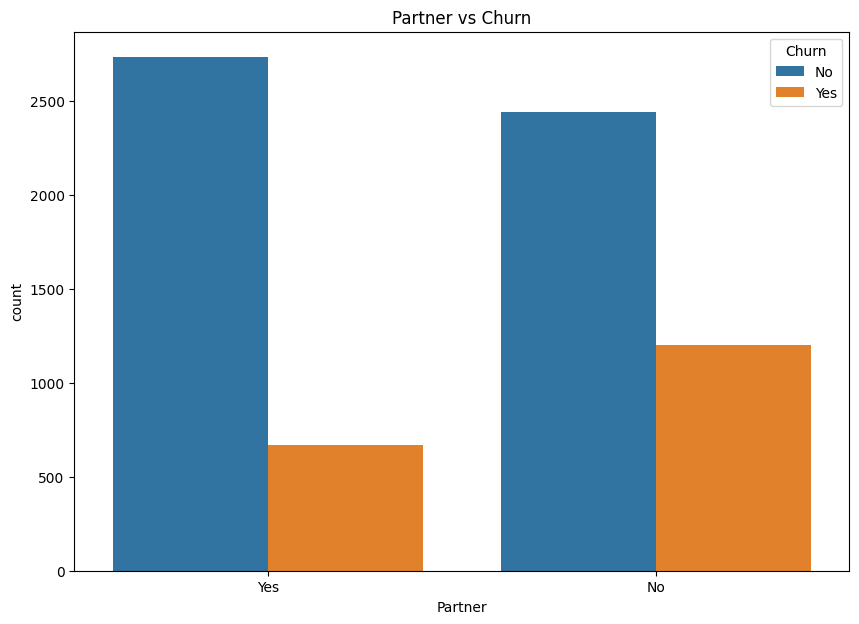

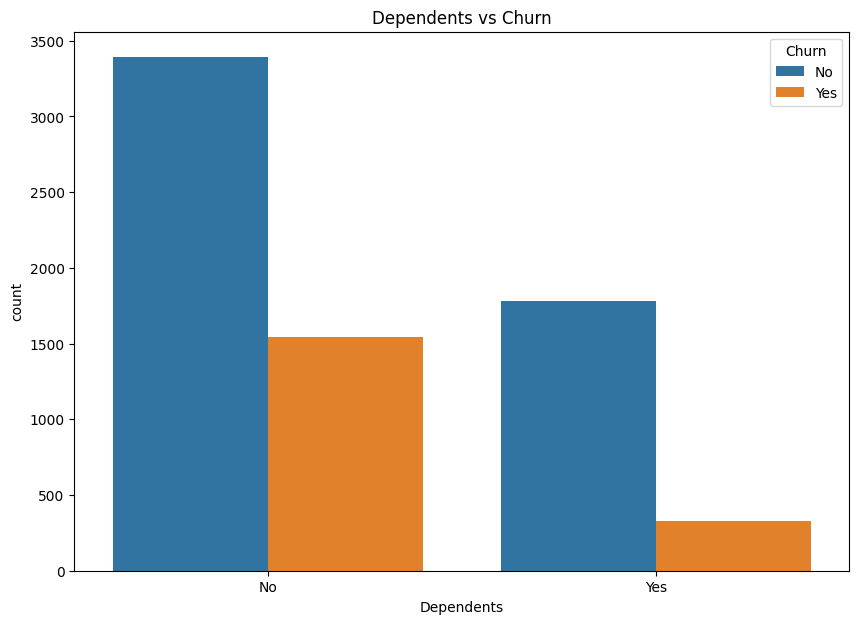

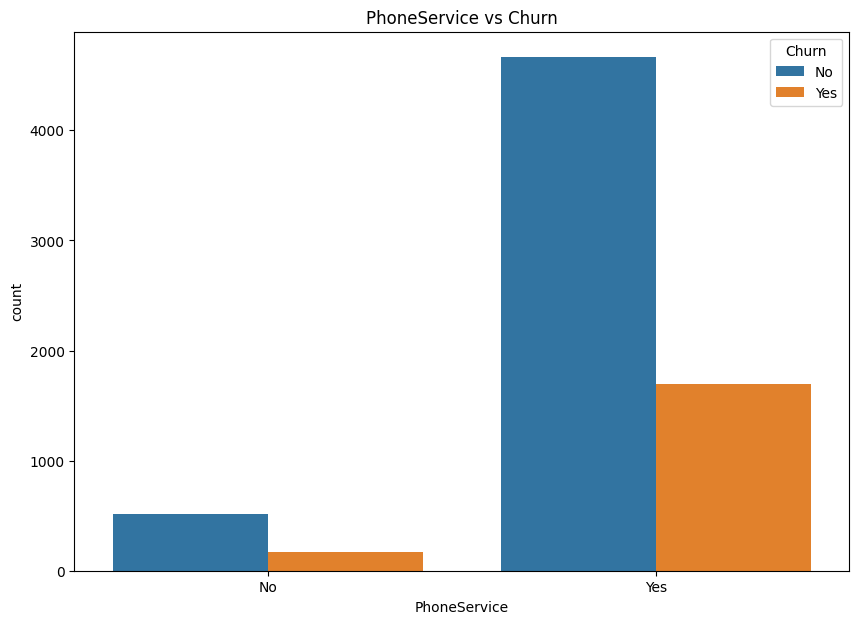

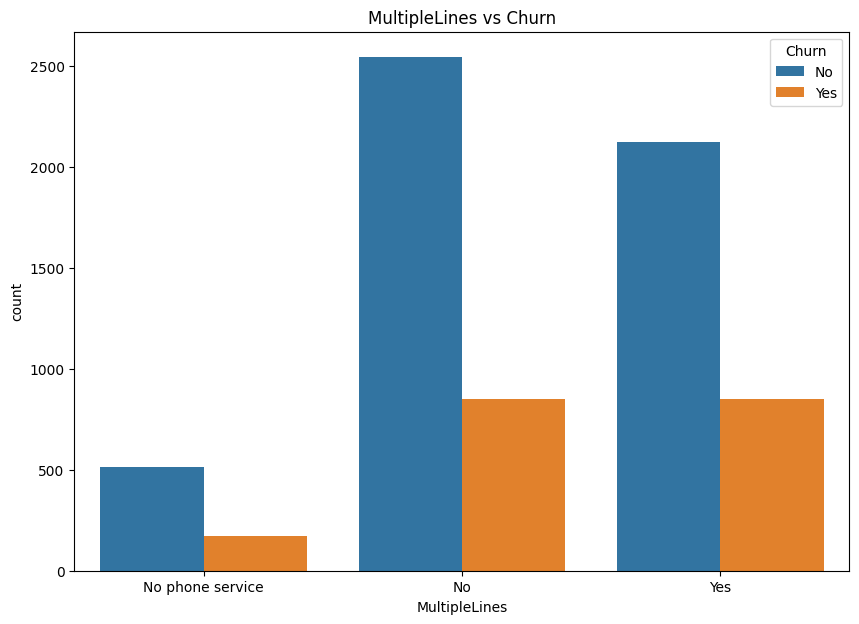

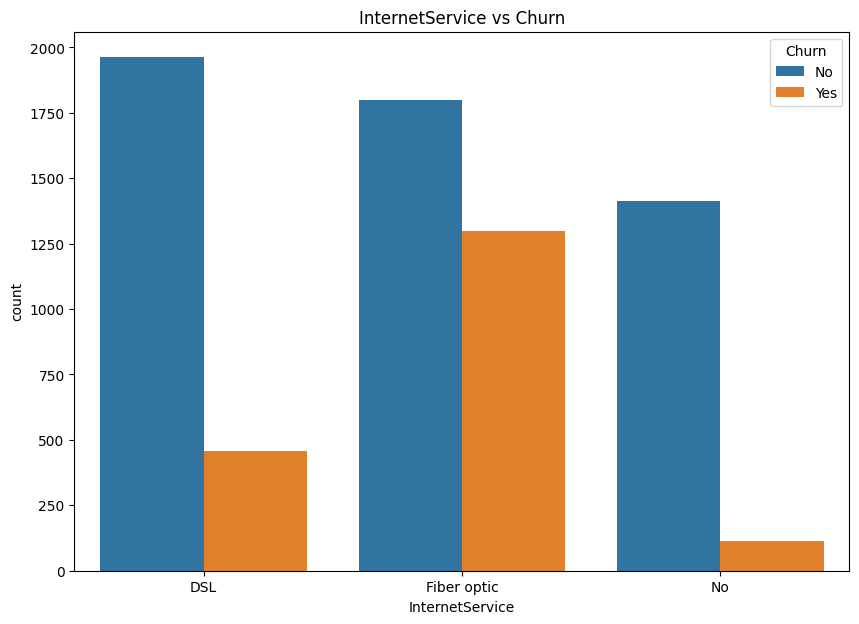

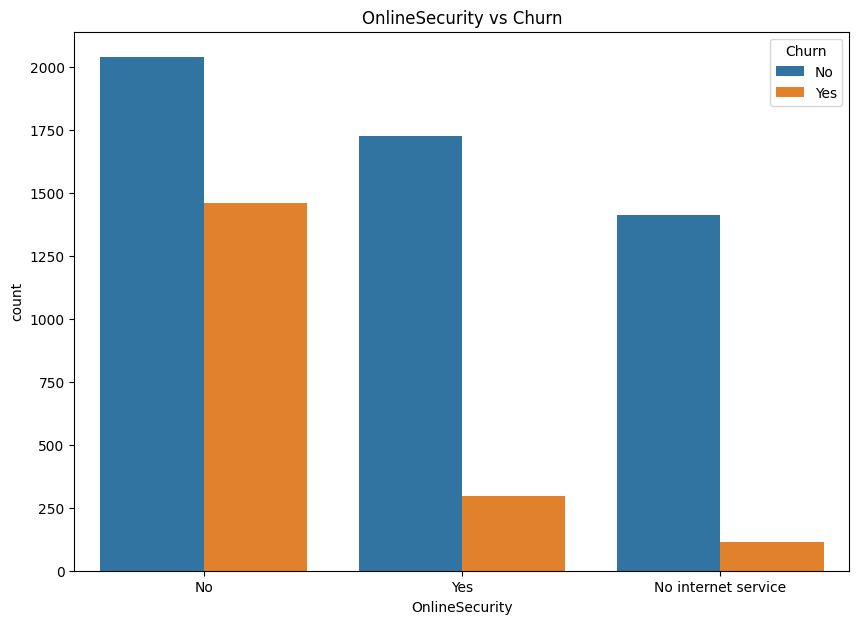

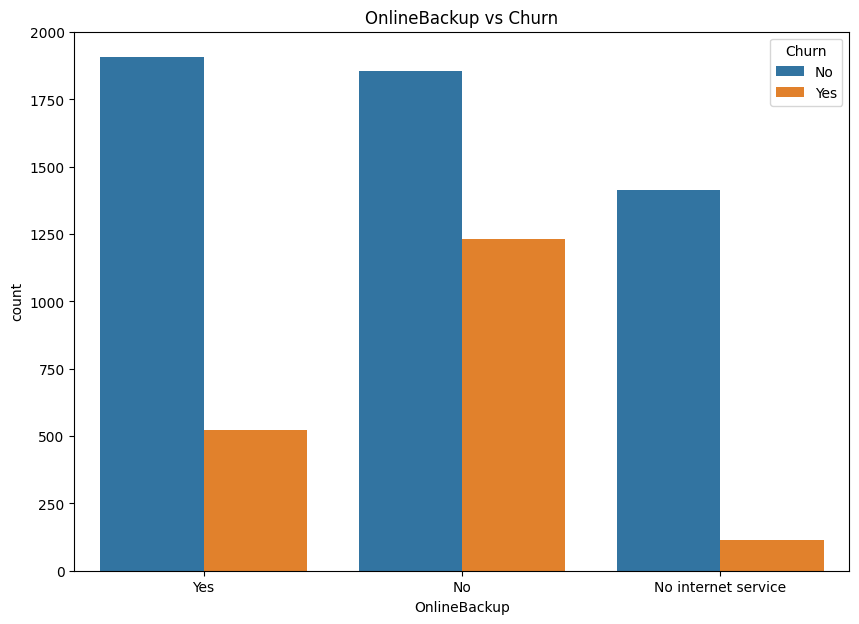

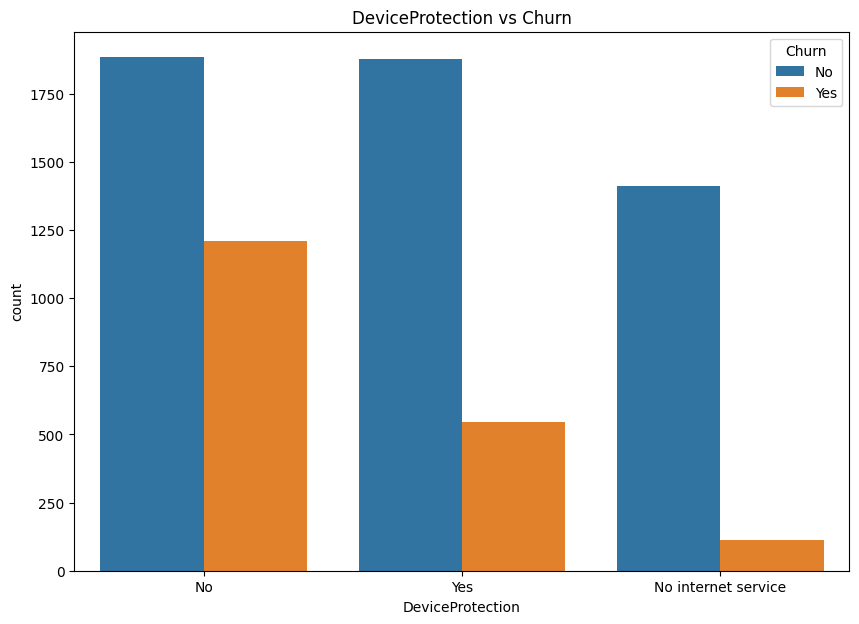

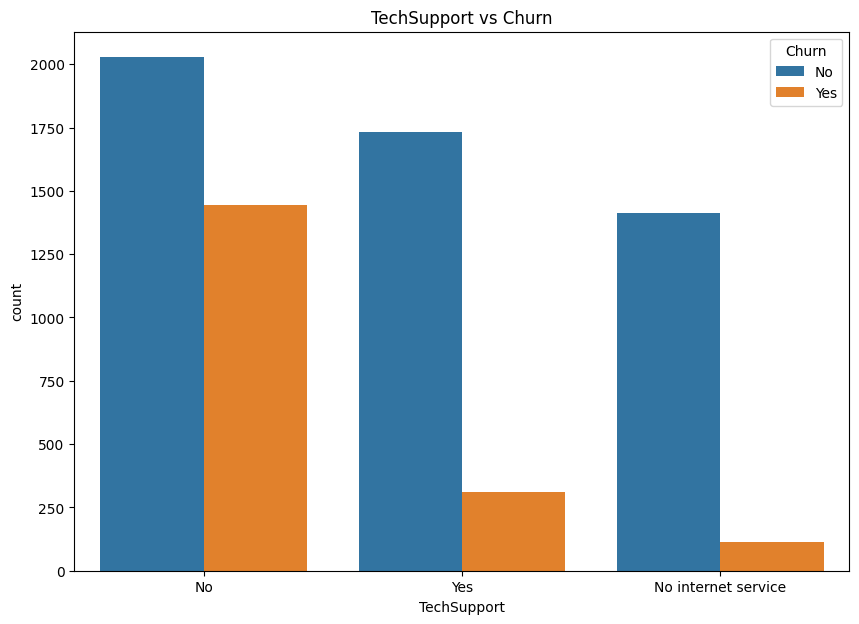

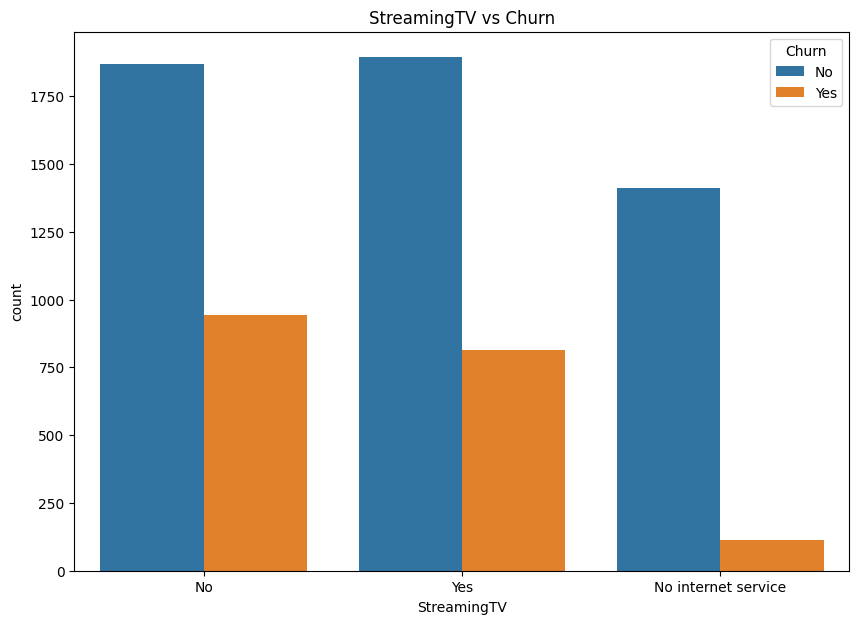

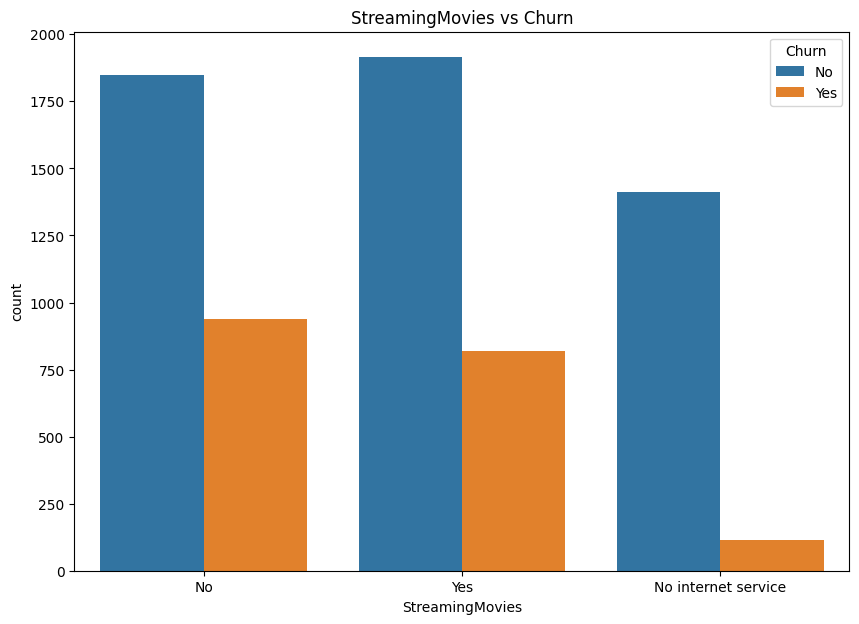

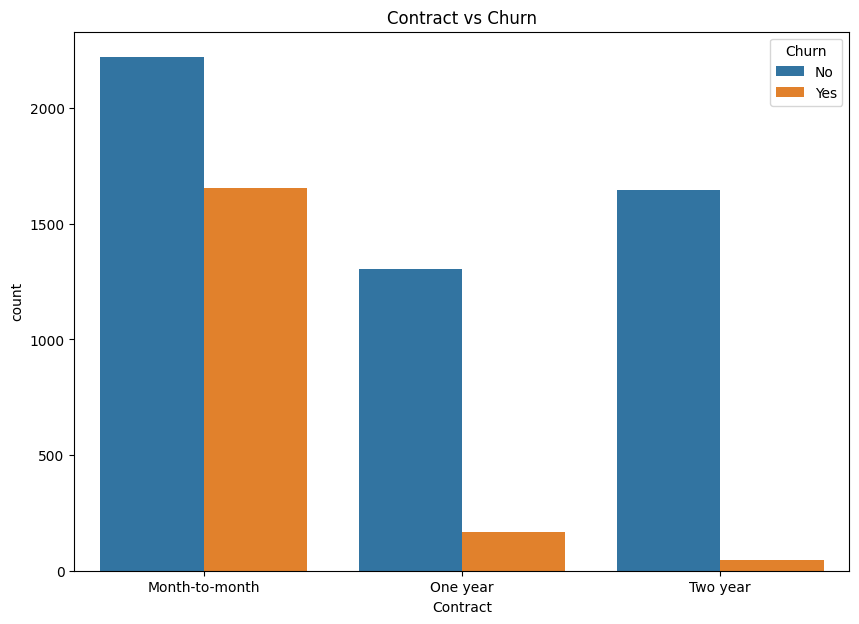

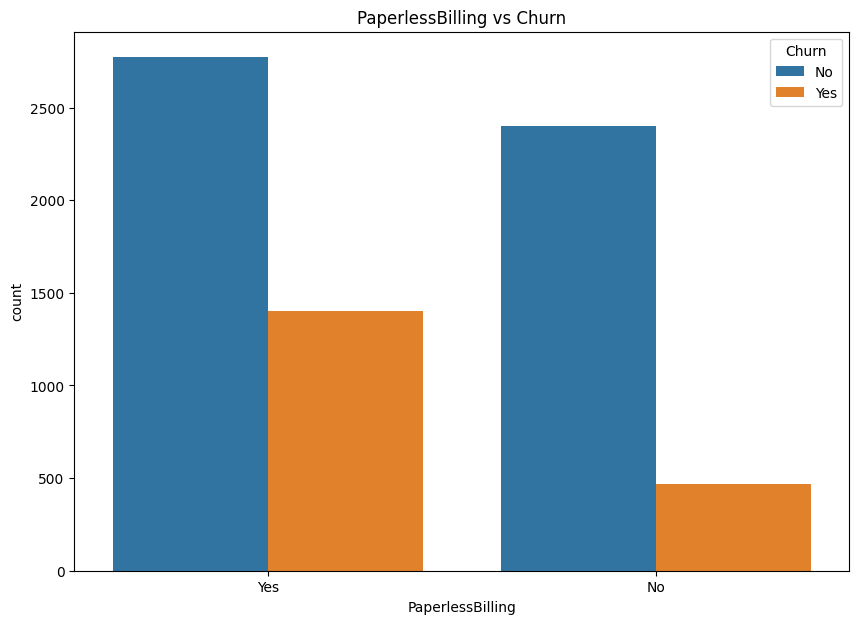

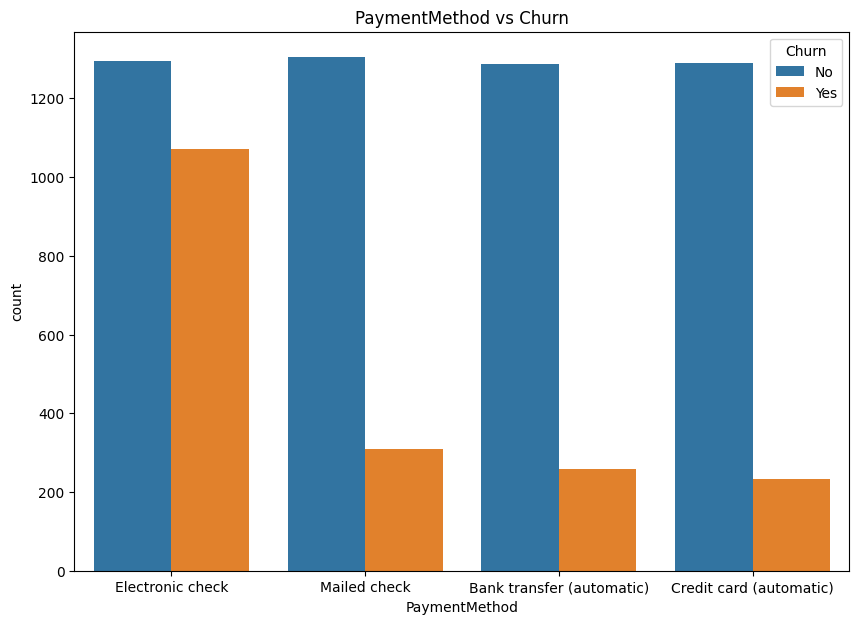

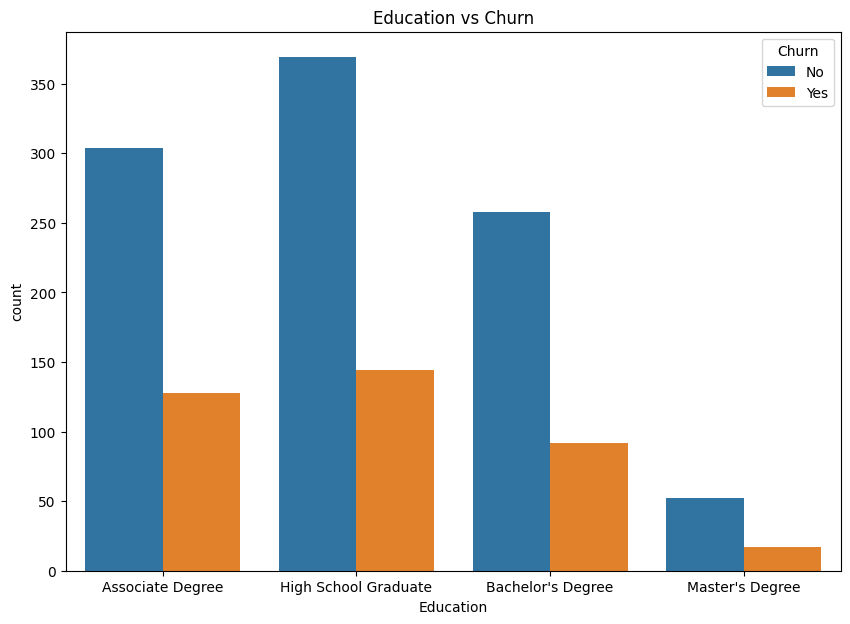

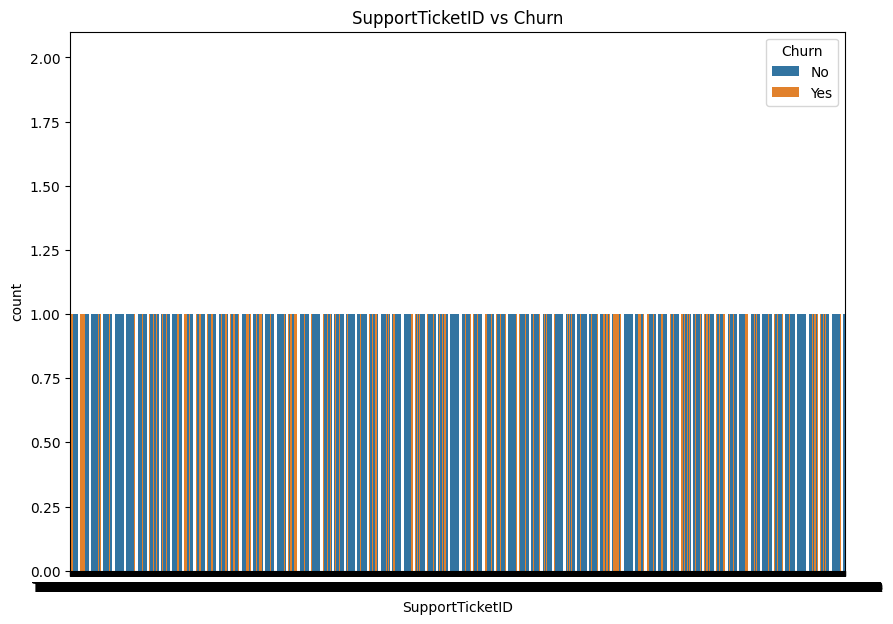

In [ ]:
#recalculate the categorial features
categorical_features = df.select_dtypes(include=[object])
#go through every attributes
for col in categorical_features:
  if col != 'Churn': #Ensure the churn is not plotted against churn
    plt.figure(figsize = (10, 7)) #set the size
    sns.countplot(data=df, x=col, hue="Churn") #color code the churn

    #label the graphs
    plt.title(f'{col} vs Churn')
    plt.xlabel(f'{col}')

    #display
    plt.show()

3. Interpret any interesting information that might help you to make any decision on combining, removing, or adding features based on that, or any resampling/rebalancing may be needed. Use a bullet point for each decision you make, with the reasoning behind the decision. While explaining, try to use the terminology we have learned in class/notes.

*   CustomerID needs to be removed when working against the target feature. This is because, it's got high cardinality, close to the number of instances we have. It's just a nominial variable to identify the customer.

*   SupportTicketID needs to be removed when working against the target feature. This is because, it's got high cardinality, close to the number of instances we have. It's just a nominial variable to identify the customer.

*   The PhoneService and MultipleLines can be either removed or combined because PhoneService is repeated again in the MultipleLines category with "no phone service".

*   The "no" InternetService part overlaps with OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingMovies categories under the "no internet service". These can be either removed or combined to reduce redundancy and irregular cardinality.

*   Last but not the least, the samples size for the customers with "No" in terms of churning are more than those with "Yes". Here, data needs to be resampled using either oversampling using SMOTE for the "Yes" or undersampled for the "No".



4. Finally, discuss at least one interesting finding from the plots in non-technical terms (which is not part of the points you have mentioned already). As an example, in a house price data set, the data shows that the houses in this zip code are more expensive, the majority of houses are in that zip code, etc.

From the above obervation, I want to discuss something interesting about the paymentMethod category. The customers who are enrolled in automatic bank transfer or credit card tend to stay with the company more than those who are not.

#D.  Understanding Numerical Attributes

For each numerical feature:

1. Plot the distribution using a histogram

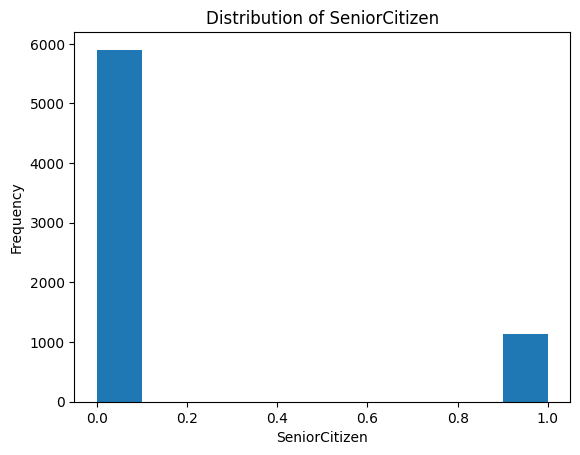

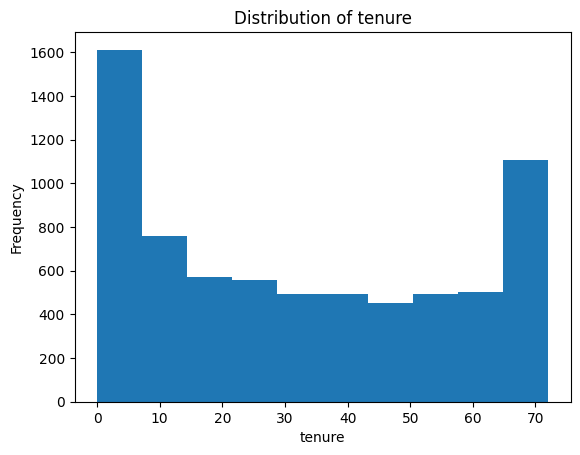

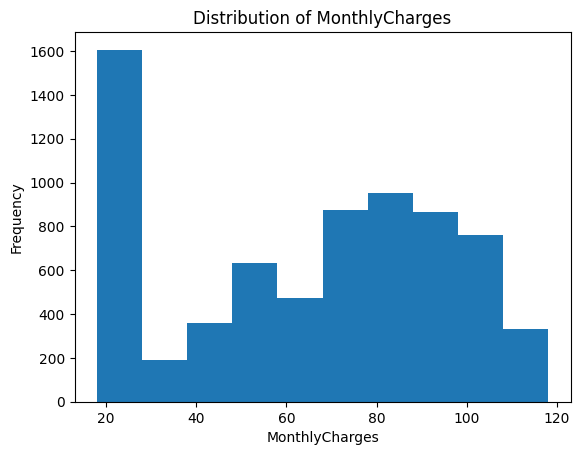

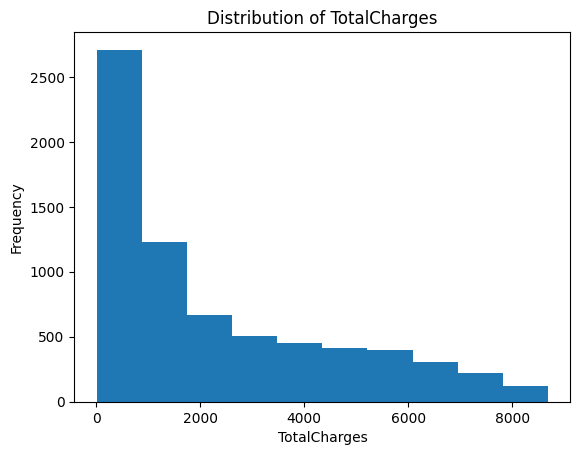

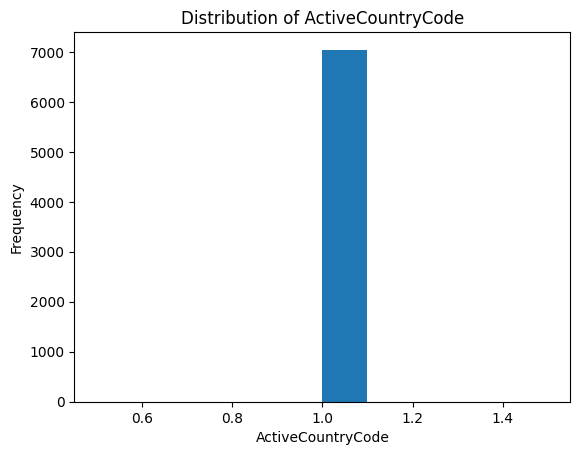

In [ ]:
#recalculate the numeric features
numeric_features = df.select_dtypes(include=[np.number])
#go through every attributes
for col in numeric_features:
  temp = df[col].dropna() #temporarily drop the NaN values
  temp.astype(int).plot.hist()

  #label
  plt.title(f'Distribution of {col}')
  plt.xlabel(f'{col}')
  plt.show()

2. Plot the distribution using seaborn distplot

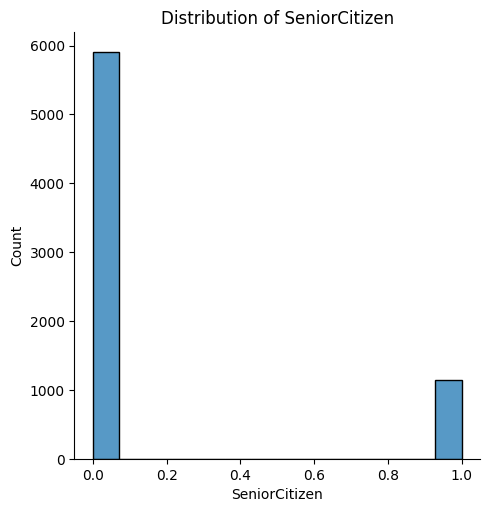

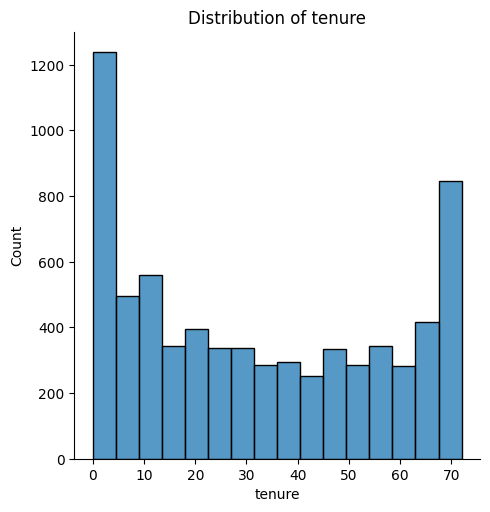

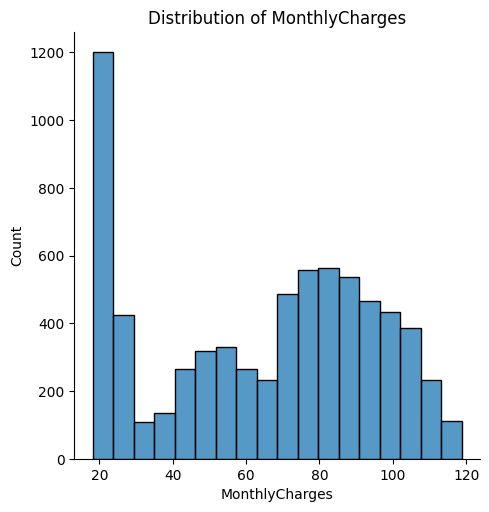

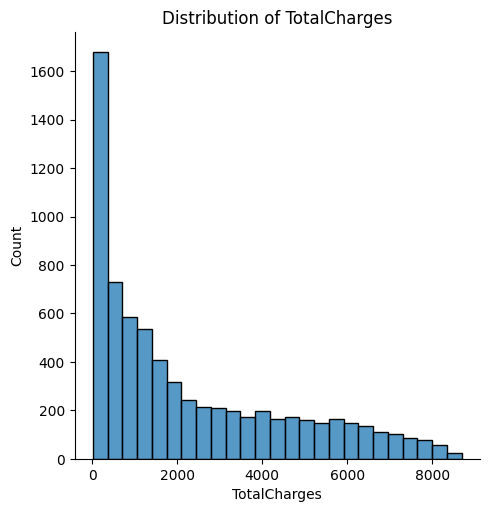

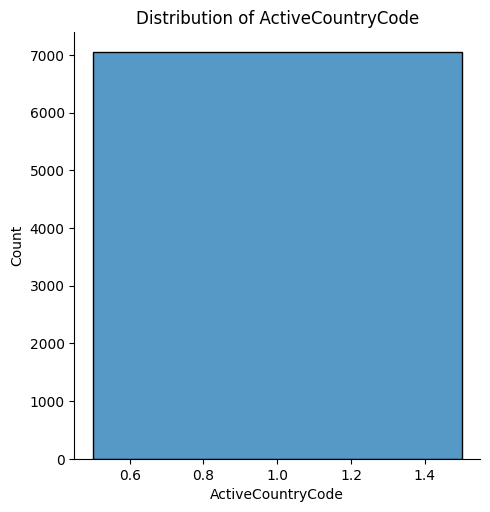

In [ ]:
for col in numeric_features: #from datacamp
  sns.displot(df[col])

  #label
  plt.title(f'Distribution of {col}')
  plt.xlabel(f'{col}')

  plt.show()

3. Interpret any interesting information that might help you to make a decision on combining, removing, or adding features based on that. Use a bullet point for each decision you make, with the reasoning behind the decision. While explaining, try to use the terminology we have learned in class/notes.

*   The SeniorCitizen is greatly skewed with bimodal. It's values are binary representation. Thus, it needs to be treated as a categorical feature.

*   The tenure feature is showing bimodal peaks on both ends. There can exist two distinct groups in this feature that needs to be binned separately.

*  The Monthly charge is showing bimodal peaks as well. We need to investigate further to identify the existence of distinct customers groups.

*   The TotalCharges is exponential and rightly skewed. We need to normalise this before building a model out of this.

*   The ActiveCountryCode in this case is a nominal value used to identify the country codes. This needs to be treated as a categorical feature.


4. Finally, discuss at least 3 interesting findings from the plots and discuss them in non-technical terms. As an example, in a house price data set, the plot shows that the house prices are right-skewed and the majority of the houses are within this range, etc. (which is not part of the points you have mentioned already).

*   The tenure feature shows majority of customers leave early or stay with the company for a long time. Some of the customers counts are in between these two types of customers. This can suggest the company has a 50/50 tendecy to either keep a customer that long or lose them quickly.

*  The MonthlyCharges shows some customers are paying quite a lot compared to other customers who are paying quite less.

*   In the totalCharge feature, majority of the customers have low bills compared to some customers with higher bills. There can be a case where some of the customers are long term customers and they have paid their bills more than the new customers.

#E. Correlation Analysis

1. Create a correlation heatmap for all numerical features, ensuring that the correlation values are displayed on the heatmap. Include the Churn variable in the analysis as well. Since Churn is a categorical variable, you may need to create a temporary numerical representation of its values before generating the correlation matrix.

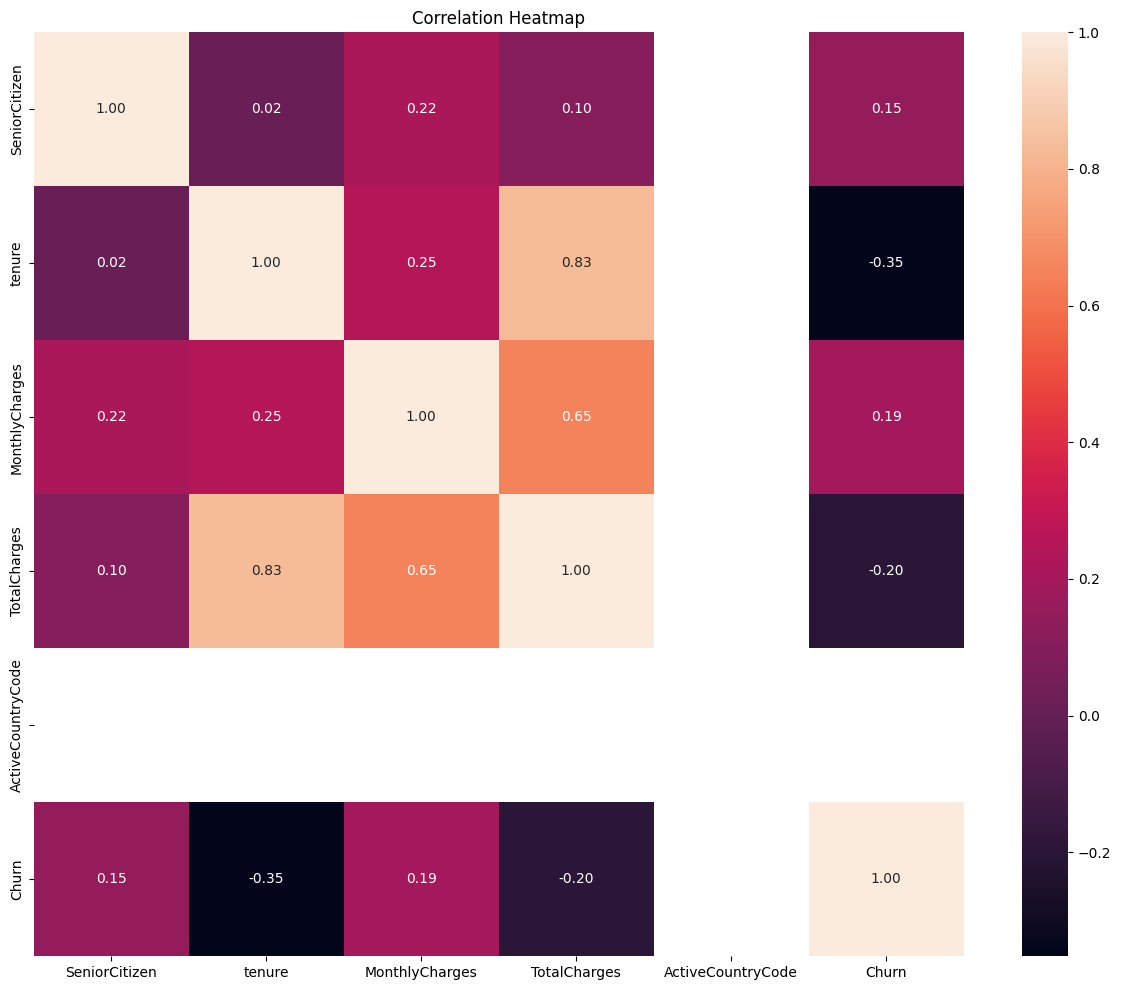

In [ ]:
#Create a temp copy of the df
df_copy = df.copy()
#make a dict for churn Yes = 1, No = 0
churn_dict = {"Yes": 1, "No": 0}
#map it to the churn column
df_copy['Churn'] = df_copy['Churn'].map(churn_dict)

#Create a new numeric feature variable
num_features = df_copy.select_dtypes(include = [np.number])
num_features.columns
correlation = num_features.corr()

#Plot the heatmap
plt.figure(figsize = (15, 12))
sns.heatmap(correlation, annot=True, xticklabels=num_features.columns, yticklabels=num_features.columns, fmt='.2f') #use at least 2 decimal value to see the correlations

plt.title('Correlation Heatmap')

plt.show()

2. Show scatter plots or boxplots between numerical features and the target to show the relationships

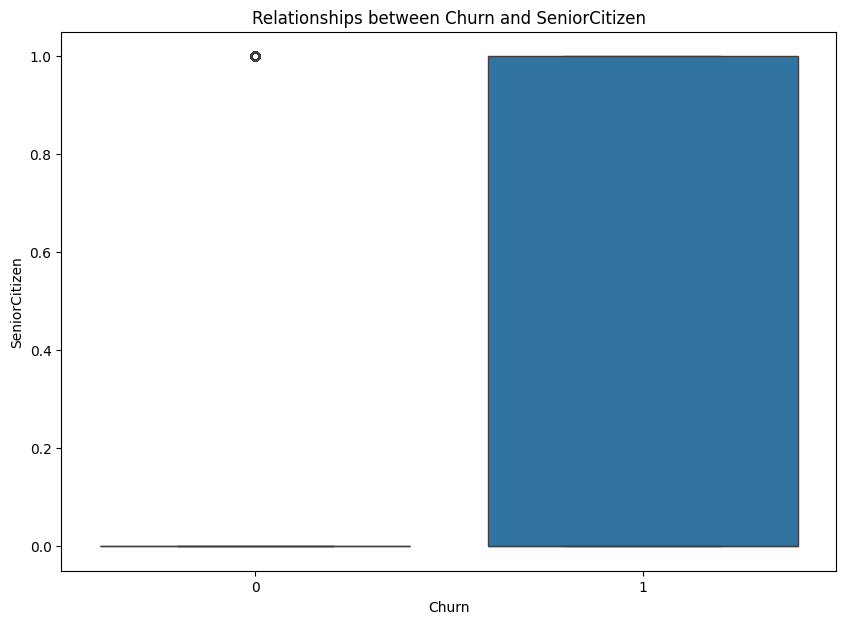

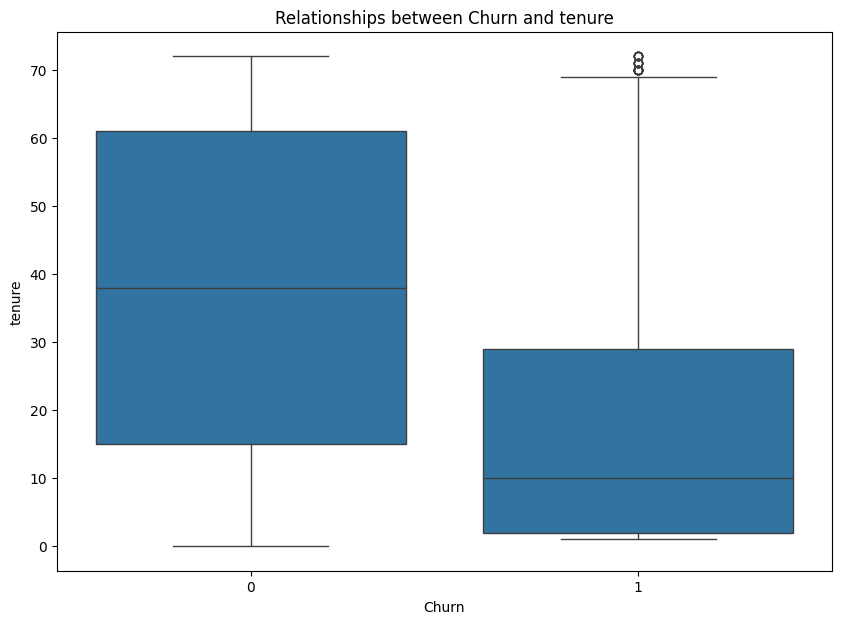

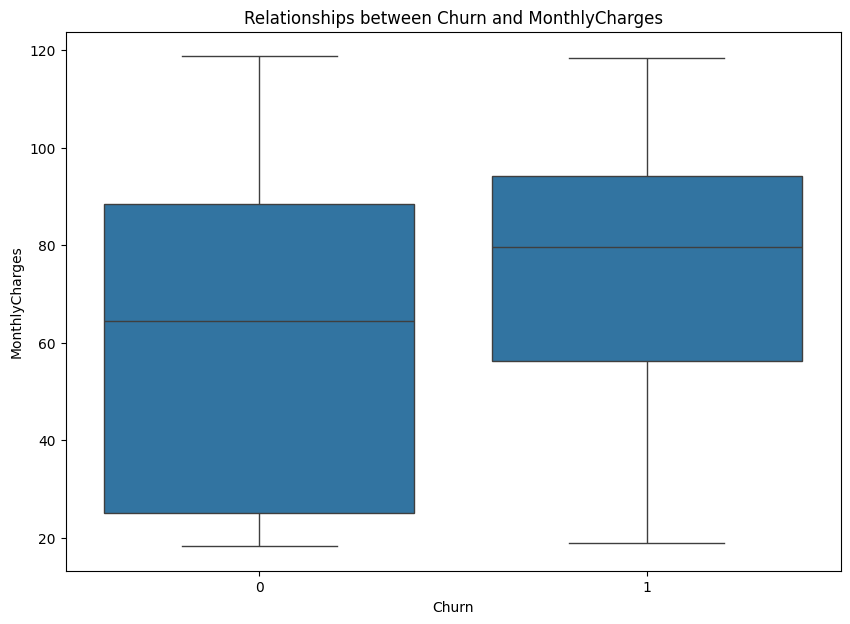

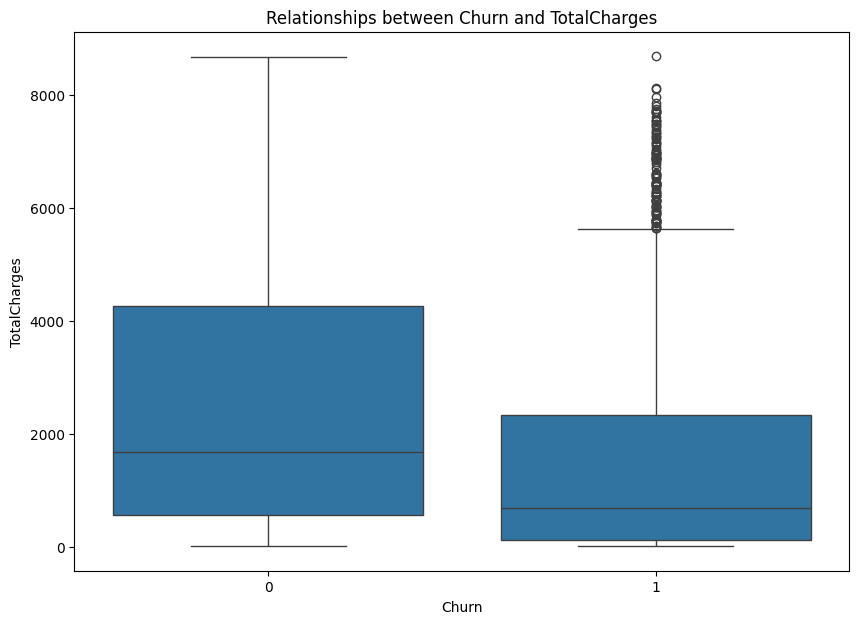

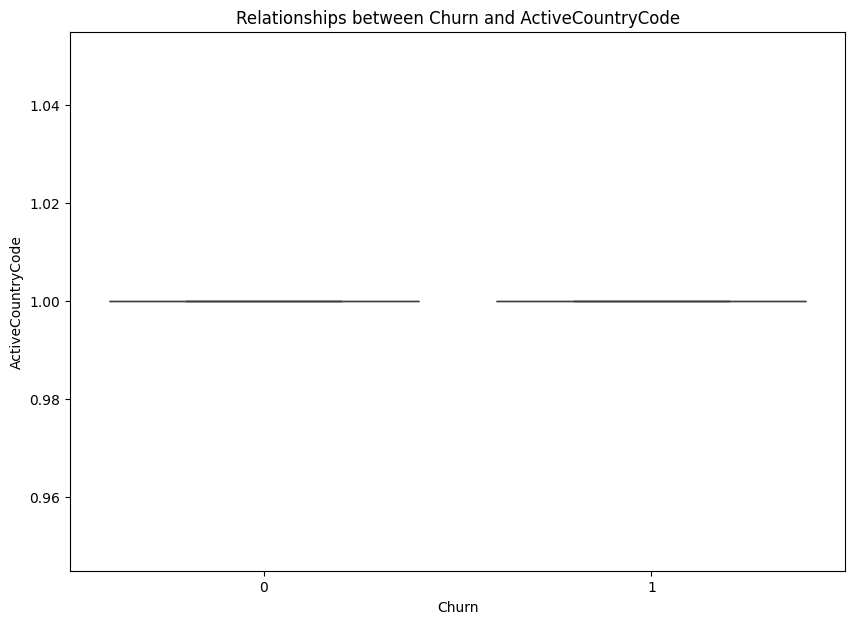

In [ ]:
#use the temporary copy made to turn Churn into a numeric feature.

#use that to go through every col and plot the boxplot for all numeric features
for col in num_features:
  if col != 'Churn': #Ensure the churn is not plotted against churn
    plt.figure(figsize = (10, 7)) #set the size
    sns.boxplot(data=df_copy, x="Churn", y=col)

    #label the graph
    plt.title(f'Relationships between Churn and {col}')
    plt.xlabel('Churn')
    plt.ylabel(f'{col}')

    plt.show()

3. Interpret and explain any findings that can lead you to drop or combine features. Use the correct technical terms we learned in the class/notes

The ActiveCountryCode from the heatmap matrix is seen white colour which signifies there's not relationship with any features. Similarly the boxplot shows both boxplots are identical. Thus, this column should be dropped.

The TotalCharges boxplot has some outliers that needs to be normalised before building a model. We need to set remove data that are greater than 75th percentile + (1.5 * IQR)

We need to remove the multicollinear features. TotalCharges and tenure have a collinearity of 0.83 according to heatmap. This may cause redundancy and can confuse the model when building it.




4. Discuss at least 2 more interesting pieces of information you got in a non-technical term from the matrix/plots with a relation to churn.

*   Senior Citizens tend to churn more than non senior citizens according to the box plots' huge height differences.

*   Customers with lower TotalCharges tend to churn than customers with higher TotalCharges. The long term customers are the ones with greater totalCharges as they paid more during their time with the company than the new customers



#F. Outliers

1. Use boxplots or other appropriate methods to detect outliers

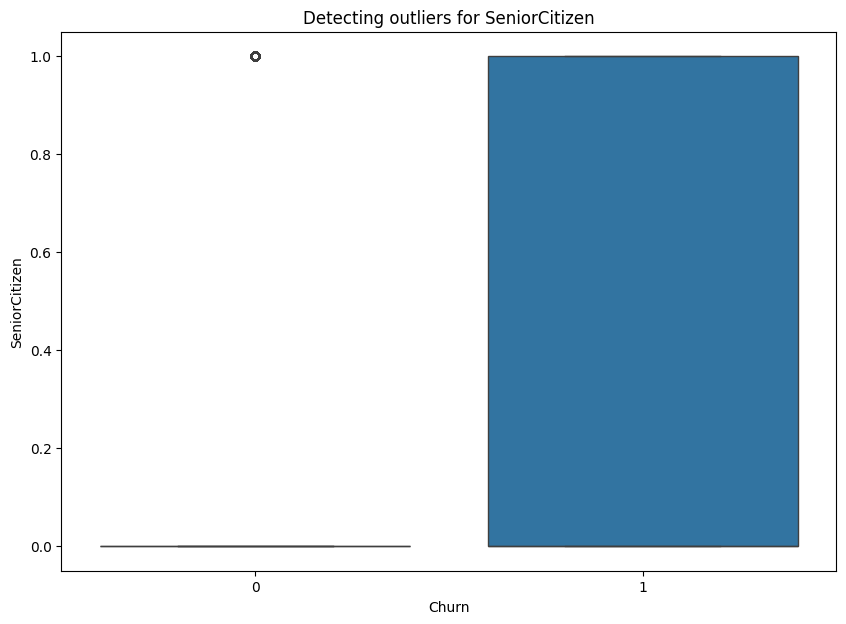

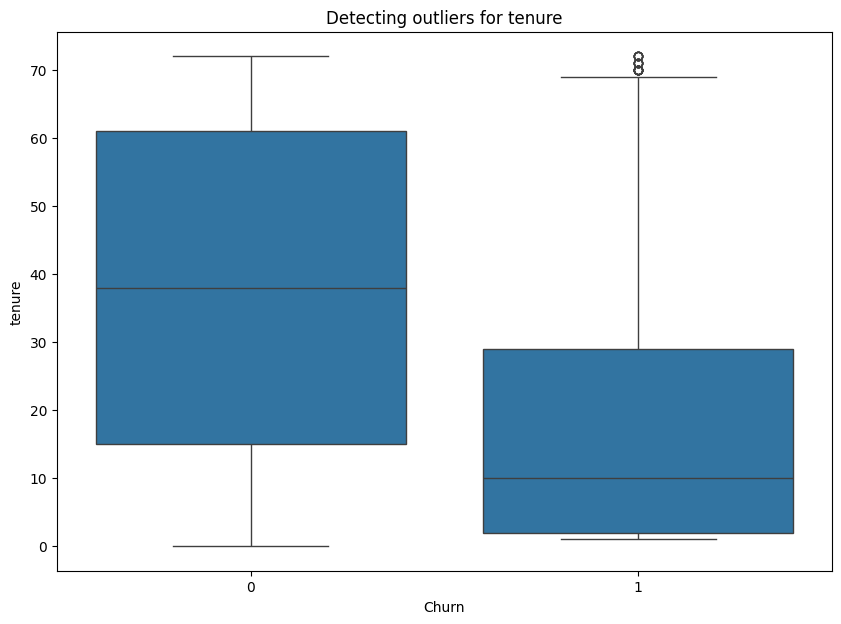

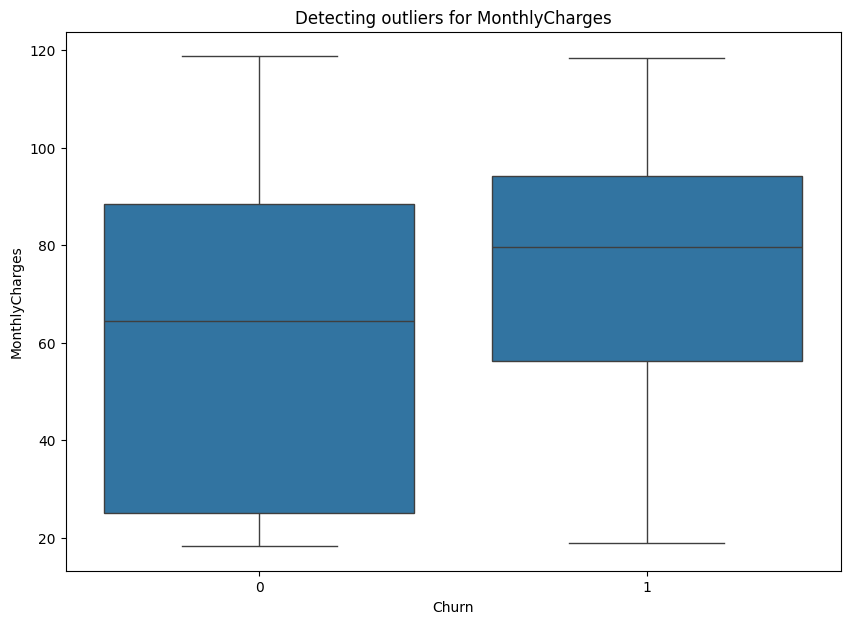

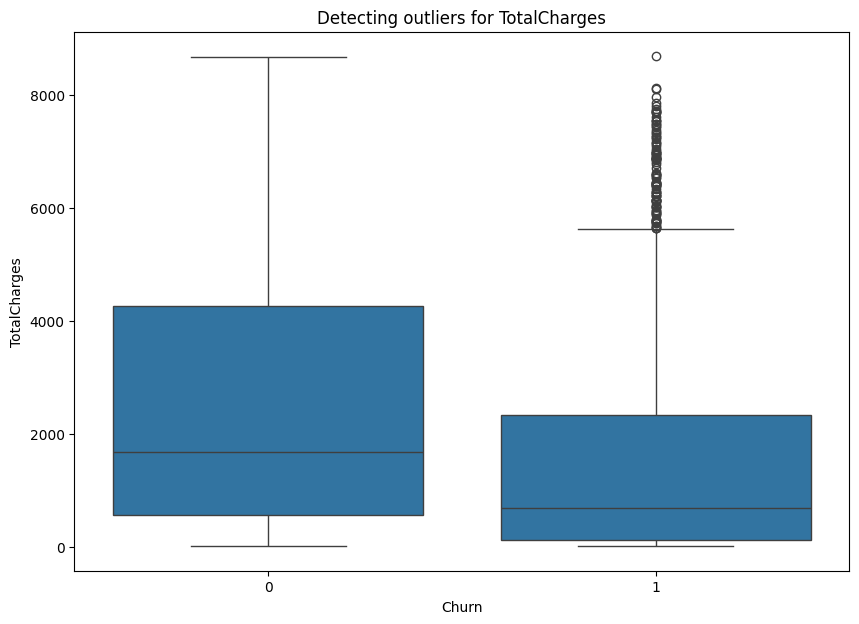

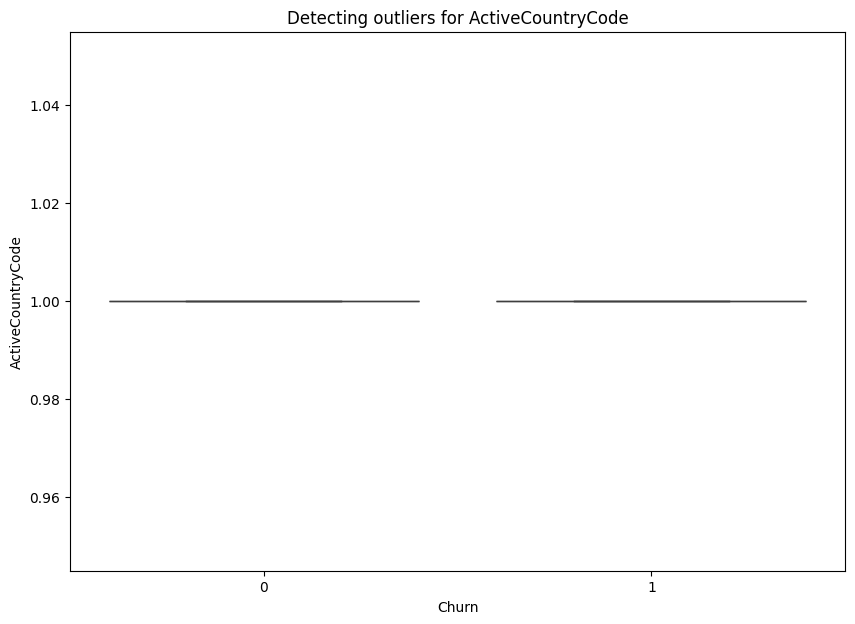

In [ ]:
#use the temporary copy made to turn Churn into a numeric feature.

#use that to go through every col and plot the boxplot for all numeric features
for col in num_features:
  if col != 'Churn': #Ensure the churn is not plotted against churn
    plt.figure(figsize = (10, 7)) #set the size
    sns.boxplot(data=df_copy, x="Churn", y=col)

    #labels
    plt.title(f'Detecting outliers for {col}')
    plt.xlabel('Churn')
    plt.ylabel(f'{col}')

    #display
    plt.show()

In [ ]:
#from the above, we need to recheck monthlycharges, total charges and tenure using the describe method
print(df_copy[['tenure','MonthlyCharges','TotalCharges']].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000


2. Discuss your observations

We can see from the above that TotalChargres has mean 2283.300441, which is greater than it's median 1397.475000, by 885.825441 from the median. Thus, we'll remove data that are beyond 75th percentile + (1.5 * IQR) to deal with the outliers.

#G. Transforming tenure

1. Identify the different values in the tenure feature

[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


<Figure size 1000x700 with 0 Axes>

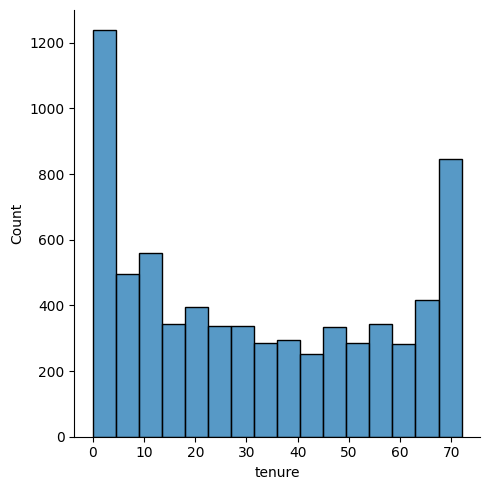

In [ ]:
plt.figure(figsize = (10, 7)) #specify the size
print(df['tenure'].unique()) #print the unique values
print(df['tenure'].describe()) # print the statistics visualisation
sns.displot(df['tenure'])
plt.show()

From the tenure feature diagram plotted in D2 as distribution plot, there can exist two distinct groups in this feature that needs to be binned separately. There are customers who stayed long with the company, customers who left early and some in between customers

2. Categorize tenure into three groups: 0, 1, and 2

We can categorize in the tenure using the equal width binning technique. This is because the tenure is calculated on monthly basis and we can easily split them into three groups.

In [ ]:
print(df[['tenure']].describe())

            tenure
count  7043.000000
mean     32.371149
std      24.559481
min       0.000000
25%       9.000000
50%      29.000000
75%      55.000000
max      72.000000


max = 72, min = 0
range = 72 - 0 = 72
bin width = 72 / 3 = 24

bin intervals:
1. Group 0: [0-24]
2. Group 1: [25-48]
3. Group 2: [49-72]

In [ ]:
#from datacamp, use the pd.cut method to bin the tenure
df['tenure_groupped'] = pd.cut(df['tenure'], bins=[0, 24, 48, 72], labels=[0, 1, 2], include_lowest=True)

#display
print(df['tenure_groupped'].value_counts())

tenure_groupped
0    3210
2    2239
1    1594
Name: count, dtype: int64


3. Explain your categorization logic

We categorized in the following way because:

*   The tenure is calculated on monthly basis and we can easily split them into three groups using the equal-width binning.

*   The tenure is grouped into three different groups: short term, mid range and long term customers.

#H. Summary and Discussion

Finally, after all the above EDA, summarize your findings, next course of action, such as we may need to transform the distribution because of right skew etc, need to remove a particular column for any reasons, remove records for any reasons, need to rebalance data, and what are the rebalancing options (if needed), and any other findings. During this time, you need to repeat some findings and actions you have mentioned earlier

Summary of my findings

CustomerID, SupportTicketID, ActiveCountryCode needs to be dropped when building a model against the target feature as they are nominal variables used to identify someone or something.

The education column, that can be seen from section A, has missing around 80% that is more than the 60% rule of thumb and thus we need to drop this column.

The TotalCharges is just less than 1% which is less than 30%. Thus, we can just simply impute the missing value by replacing it with a mean, median, mode, or other aggregate value since a small number of features are missing. We can also build a predictive [regression] model based on the dataset to try and predict the missing feature.

From C1 and C2, by observing the barplot and the countplot, I decided to do the following:

1. The PhoneService and MultipleLines can be either removed or combined because PhoneService is repeated again in the MultipleLines category with "no phone service".

2. The "no" InternetService part overlaps with OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingMovies categories under the "no internet service". These can be either removed or combined to reduce redundancy and irregular cardinality.

3. The samples size for the customers with "No" in terms of churning are more than those with "Yes". Here, data needs to be resampled using either oversampling using SMOTE for the "Yes" to generate more synthetic data or undersampled for the "No" to remove majority class. Some of the overlapping features such as InternetService, MultipleLines etc needs to be combined. Both the undersampling and oversampling methods can be combined to achieve a balanced proportionality.

From D1 and D2, we observed the histogram and distribution plot to decide the following:
1. The tenure feature is showing bimodal peaks on both ends. There can exist two distinct groups in this feature that needs to be binned separately. We did equal width binning as seen in G into three groups of customers.

2. The Monthly charge is showing bimodal peaks as well. We need to investigate further to identify the existence of distinct customers groups and separate them.

3. The TotalCharges is exponential and rightly skewed. We need to normalise this before building a model out of this.

 From E1, by paying attention to the heatmap, we needs to:

 1. Address the multicolinearlity. The features, tenure and TotalCharges, are highly correlated with 0.83 based on the heatmap.

From F, with the help of the boxexnplot and the describe method, we identified the outlier:
1. TotalChargres has mean 2283.300441, which is greater than it's median 1397.475000, by 885.825441 from the median. Thus, we'll remove data that are beyond 75th percentile + (1.5 * IQR)

Overall, we need to clean the data and rerun the analysis test whether our dataset is ready to be used to build our model.